# Final Project — Phân loại ảnh nội soi tiêu hoá (GastroVision)

**Môn:** AIN501 — Deep Learning &nbsp;&nbsp;|&nbsp;&nbsp; **Nhóm:** 2 thành viên

---

## 1. Đề bài

> Chọn một bài toán có **baseline đã công bố**, tái lập baseline đó, rồi **đề xuất cải tiến vượt qua nó** —
> có bằng chứng thống kê, không phải một con số may mắn.

**Dataset:** [GastroVision](https://github.com/DebeshJha/GastroVision) — ~8.000 ảnh nội soi đường tiêu hoá,
27 lớp, dùng **22 lớp** (theo luật của bài báo: lớp có > 25 ảnh).
**Baseline đã công bố:** DenseNet-121 → macro-F1 **0,6504** (arXiv 2307.08140, Table 2).

## 2. Tóm tắt cách làm

| Bước | Nội dung |
| --- | --- |
| **Dữ liệu** | 22 lớp, chia **phân tầng 60:20:20** với `SPLIT_SEED = 42` cố định cho cả nhóm |
| **Kiểm định dữ liệu** | Phân bố long-tail, **audit rò rỉ** giữa 3 tập: trùng byte (MD5) + gần trùng (cosine trên embedding) |
| **2 baseline** | **DenseNet-121** (CNN — có số để khớp) và **Swin-T** (Transformer — bài báo không có, đóng góp của nhóm) |
| **Mô hình đề xuất** | **CoAtNet-0** (lai conv + attention) + công thức đã chứng minh có tín hiệu (độ phân giải, TTA, ensemble checkpoint) |
| **Chống nhiễu phép đo** | Giữ **top-3 checkpoint + checkpoint theo val trung bình trượt**, 3 seed, **bootstrap CI**, lưu **logits** để mọi phân tích sau đều không tốn GPU |
| **Chỉ số** | **macro-F1** (bắt buộc với dữ liệu mất cân bằng) + micro-F1 + F1 từng lớp + ma trận nhầm lẫn |
| **Triển khai** | Xuất ONNX, đo độ trễ và kích thước mô hình |

### Bốn cấu hình, **hai** baseline — bảng tra nhanh

| Mã | Mô hình | Vai trò | Có phải baseline? |
| --- | --- | --- | --- |
| `B0` | DenseNet-121 @224 | **Baseline 1** — CNN tham chiếu, phải khớp **0,6504** của bài báo | ✅ |
| `S0` | Swin-T @224 | **Baseline 2** — Transformer; bài báo **không có** nhánh này | ✅ |
| `P0` | CoAtNet-0 @224 | **bước trung gian** — để `P0` → `P1` chỉ đổi đúng *một* thứ: độ phân giải | ❌ |
| `P1` | CoAtNet-0 @288 | **mô hình đề xuất** (+ TTA + ensemble top-3 checkpoint) | ❌ |

**Chỉ có hai baseline.** Table 2 của bài báo liệt kê 6 mô hình (ResNet-50, ResNet-152,
EfficientNet-B0, DenseNet-169, ResNet-50 pretrained, DenseNet-121) — đó là **số công bố của họ**;
notebook này huấn luyện lại **đúng một** dòng trong số đó, DenseNet-121, vì nó là dòng mạnh nhất.

Mọi tên phương pháp khác xuất hiện phía dưới đều là **đòn bẩy**, không phải mô hình mới và không
phải baseline. Chúng chia làm hai nhóm, và **đừng lẫn hai nhóm này**:

* **Đo trong chính notebook này, trên đúng bốn cấu hình trên:** 3 quy tắc chọn checkpoint × 2 chế
  độ TTA (= 6 cột ở mục 16), hiệu chỉnh logit (mục 18 + 19b), 4 điều kiện transfer learning (mục 19d).
* **Đo ở vòng thí nghiệm đầu tiên, mã `B2`/`B3`/`B4`/`B5`, chỉ còn trong `RESULTS.md` §6:**
  augment mạnh, Balanced-Softmax, cRT, DenseNet-121 @288. **Notebook này không chạy lại chúng** —
  chúng chỉ được trích làm lý do cho các lựa chọn thiết kế ở mục 3 và mục 9. Hệ mã `B2`…`B5` **không**
  thuộc hệ mã `B0/S0/P0/P1` ở bảng trên; riêng `B0` là tên dùng lại nhưng số thì khác hẳn.

## 3. Bài học đã trả giá bằng thí nghiệm (đọc trước khi chạy)

Vòng thí nghiệm đầu tiên (ghi đầy đủ trong `RESULTS.md`) cho ra ba kết luận định hình toàn bộ notebook này:

1. **Ba kỹ thuật xử lý mất cân bằng đều không ăn thua** — Balanced-Softmax (−0,007), cRT (−0,013),
   công thức fine-tune 2 giai đoạn + augment mạnh (−0,035). Nút thắt **không** nằm ở hàm mất mát hay
   ở biên quyết định của classifier, mà ở **chất lượng biểu diễn đặc trưng**.
2. **Nhiễu giữa các lần chạy (~±0,02–0,05) LỚN HƠN mọi hiệu ứng đo được.** Vì vậy **không con số
   1-seed nào được trích vào báo cáo** — mọi thứ phải là trung bình ± độ lệch chuẩn trên 3 seed, kèm CI.
3. **Chọn checkpoint theo val tốt nhất là nguồn nhiễu thứ hai**: ở vòng thí nghiệm trước,
   DenseNet-121 @288 đạt val 0,689 — cao nhất trong mọi bậc — nhưng test chỉ 0,634. Khoảng cách
   val/test 0,055 trên một seed chính là chân dung của nhiễu. *(Cấu hình đó không có trong
   notebook này; đòn bẩy độ phân giải giờ được đo trên backbone đề xuất — xem mục 15b.)*
   Notebook này giữ **3 quy tắc chọn checkpoint cùng lúc trong một lần chạy**, mỗi quy tắc đo cả
   khi có và khi không có TTA (**= 6 cột ở mục 16**), để so sánh mà không tốn thêm epoch.

> Hệ quả thiết kế: mọi thứ tốn GPU chỉ chạy **một lần**, và mọi phân tích về sau (CI, ensemble,
> hiệu chỉnh logit, chọn quy tắc checkpoint) đọc lại từ **logits đã lưu** — 0 epoch.

---
## 4. Cách chạy

### Trên Google Colab (chế độ chạy thật)
1. `Runtime → Change runtime type → GPU` (**T4** đủ chạy; **A100** nhanh hơn ~3× nhờ bf16 + TF32 —
   batch **vẫn giữ 32** vì batch là một phần của giao thức, xem mục 5).
2. `Run all`. Lần đầu notebook tự tải `Gastrovision.zip` (~1,8 GB) và giải nén.
3. Checkpoint + logits được ghi vào Google Drive nên **mất kết nối không mất kết quả**.

### Trên máy cá nhân không có GPU (chế độ kiểm thử)
Notebook tự nhận ra không có CUDA và chuyển sang hồ sơ **`cpu-smoke`**: vẫn **đủ 22 lớp, vẫn đúng
4 cấu hình** (`B0`/`S0`/`P0` ở 224 và `P1` ở 288), chỉ giới hạn số ảnh mỗi lớp và số epoch. Mục đích
là **bắt sạch lỗi trước khi lên Colab**, không phải để lấy số chính xác.

> ⚠️ Số đo ở `cpu-smoke` **không có giá trị khoa học** (mỗi lớp chỉ vài ảnh test). Notebook sẽ in cảnh
> báo này ở mọi bảng kết quả khi đang ở chế độ đó.

In [1]:
# Kiem tra GPU truoc khi lam bat cu viec gi khac.
# Khong co GPU van chay duoc: notebook se tu chuyen sang ho so "cpu-smoke".
!nvidia-smi || echo "KHONG THAY GPU -> se chay ho so cpu-smoke (chi de kiem thu code)"

Thu Aug 27 07:24:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%%capture
# timm  : nguon Swin-T / CoAtNet-0 (Colab khong cai san)
# onnx* : can cho phan xuat mo hinh o muc 20 (torch 2.9+ dung bo xuat dua tren torch.export)
# gradio: demo o muc 20b -- thieu no thi o do lang le bo qua UI, va rubric mat phan "san pham"
!pip install -q timm onnx onnxscript gradio

In [3]:
import os, sys, io, json, math, time, random, hashlib, zipfile, subprocess, warnings, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

try:
    import timm
except ModuleNotFoundError:
    timm = None
    print("CANH BAO: chua co timm -> chi chay duoc DenseNet-121")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU"
print("torch      :", torch.__version__)
print("torchvision:", tv.__version__)
print("timm       :", getattr(timm, "__version__", "khong co"))
print("device     :", DEVICE, "|", GPU_NAME)

torch      : 2.11.0+cu128
torchvision: 0.26.0+cu128
timm       : 1.0.28
device     : cuda | NVIDIA A100-SXM4-40GB


---
## 5. Hồ sơ chạy (tự nhận diện phần cứng)

Một biến `PROFILE` duy nhất điều khiển toàn bộ quy mô thí nghiệm. **Code path giống hệt nhau ở cả ba hồ sơ** —
cùng 22 lớp, cùng 4 cấu hình (kể cả `P1` ở 288), cùng hàm huấn luyện/đánh giá. Chỉ **lượng dữ liệu và
số epoch** đổi.

| Hồ sơ | Kích hoạt khi | Dữ liệu | Epoch | Batch | Seed | Mục đích |
| --- | --- | --- | --- | --- | --- | --- |
| `cpu-smoke` | không có CUDA | 12/4/4 ảnh mỗi lớp | 2 | 8 | [0] | **kiểm thử code**, đo tốc độ, chạy audit dữ liệu |
| `gpu-t4` | CUDA, VRAM < 24 GB | toàn bộ | 30 | 32 | [0,1,2] | chạy thật (Colab miễn phí) |
| `gpu-a100` | CUDA, VRAM ≥ 24 GB | toàn bộ | 30 | **32** | [0,1,2] | chạy thật, nhanh hơn ~3× |

Kiểu số của AMP **không** do hồ sơ quyết định mà do **năng lực GPU**: máy nào hỗ trợ bf16
(Ampere trở lên — A100, L4) thì dùng **bf16 + TF32** và bỏ `GradScaler`; T4 không hỗ trợ nên
tự quay về **fp16 + GradScaler**. Nhờ vậy đổi loại GPU không phải sửa gì.

**Vì sao A100 vẫn giữ batch 32 chứ không tăng lên 64:** batch size là **một phần của giao thức**.
Đổi nó là đổi cả tốc độ học hiệu dụng lẫn số bước cập nhật, và con số thu được sẽ không còn so sánh
được với 0,6504 của bài báo (batch 32) hay với lần chạy B0 cũ. Lợi thế của A100 được lấy bằng
**bf16** (dải số mũ bằng fp32 nên không cần `GradScaler`, ổn định hơn fp16 của T4) và **TF32**
cho conv/matmul — tức là cùng một phép thí nghiệm, chỉ chạy nhanh hơn.

Muốn ép thủ công thì sửa `PROFILE_OVERRIDE` (ví dụ chạy `"cpu-smoke"` ngay trên Colab để thử nhanh toàn bộ notebook trong ~5 phút trước khi chạy thật).

In [4]:
# --------------------------- CAU HINH THUC NGHIEM ---------------------------
PROFILE_OVERRIDE = None      # None = tu nhan dien | "cpu-smoke" | "gpu-t4" | "gpu-a100"

SPLIT_SEED   = 42            # CO DINH cho ca nhom -> moi nguoi chia du lieu giong het nhau
IMG_SIZE     = 224
MIN_PER_CLASS = 25           # luat cua bai bao: giu lop co > 25 anh -> 22 lop
SMOOTH_WIN   = 3             # cua so trung binh truot khi chon checkpoint (quy tac "smooth")
KEEP_TOP_K   = 3             # giu top-3 checkpoint theo val -> cho phep ensemble ma khong ton epoch


def detect_profile():
    if not torch.cuda.is_available():
        return "cpu-smoke"
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    return "gpu-a100" if vram_gb >= 24 else "gpu-t4"


PROFILES = {
    "cpu-smoke": dict(epochs=2,  batch=8,  seeds=[0],       cap=(12, 4, 4),
                      workers=0, amp=False, audit_cap=2000, latency_iters=10),
    "gpu-t4":    dict(epochs=30, batch=32, seeds=[0, 1, 2], cap=None,
                      workers=2, amp=True,  audit_cap=None, latency_iters=100),
    # A100 GIU NGUYEN batch 32 chu khong tang len 64: batch la mot phan cua giao thuc, doi no la
    # doi ca toc do hoc lan so buoc cap nhat -> khong con so sanh duoc voi 0,6504 cua bai bao (batch 32)
    # va voi lan chay B0 cu. Loi the cua A100 duoc lay bang bf16 + TF32 va thoi gian cho ngan hon.
    "gpu-a100":  dict(epochs=30, batch=32, seeds=[0, 1, 2], cap=None,
                      workers=4, amp=True,  audit_cap=None, latency_iters=100),
}

PROFILE = PROFILE_OVERRIDE or detect_profile()
CFG     = PROFILES[PROFILE]

EPOCHS      = CFG["epochs"]
BATCH_SIZE  = CFG["batch"]
SEEDS       = CFG["seeds"]
NUM_WORKERS = CFG["workers"]
USE_AMP     = CFG["amp"] and DEVICE == "cuda"
PIN_MEMORY  = DEVICE == "cuda"
IS_SMOKE    = PROFILE == "cpu-smoke"

# Kieu du lieu AMP quyet dinh theo NANG LUC GPU chu khong theo ho so:
#   - bf16 co dai so mu bang fp32 -> khong can GradScaler, khong bi tran so nhu fp16.
#     Can Ampere tro len (A100 SM80, L4 SM89). T4 (SM75) khong ho tro -> tu quay ve fp16.
#   - TF32 lam conv/matmul nhanh ~1,5-2x tren Ampere, van TAT DINH (cung phep tinh -> cung ket qua),
#     chi bot do chinh xac phan dinh tri.
# Nho vay notebook dung dtype toi uu cho ca T4, L4 lan A100 ma khong can sua tay.
if USE_AMP and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
elif USE_AMP:
    AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.float32
USE_SCALER = USE_AMP and AMP_DTYPE is torch.float16

IS_AMPERE = DEVICE == "cuda" and torch.cuda.get_device_capability(0)[0] >= 8
if IS_AMPERE:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Windows + Dataset dinh nghia trong notebook -> num_workers > 0 se loi pickle (spawn).
if os.name == "nt":
    NUM_WORKERS = 0

print(f"PROFILE = {PROFILE}   (device={DEVICE}, {GPU_NAME})")
print(f"  epochs={EPOCHS}  batch={BATCH_SIZE}  seeds={SEEDS}  workers={NUM_WORKERS}")
print(f"  amp={USE_AMP} ({str(AMP_DTYPE).replace('torch.', '')})  GradScaler={USE_SCALER}"
      + ("  TF32=bat" if IS_AMPERE else ""))
print(f"  gioi han anh moi lop (train/val/test) = {CFG['cap']}")
if IS_SMOKE:
    print("\n" + "!" * 78)
    print("!! CHE DO KIEM THU: moi con so macro-F1 duoi day KHONG co gia tri khoa hoc.")
    print("!! Muc dich duy nhat: chung minh notebook chay het khong loi truoc khi len Colab.")
    print("!" * 78)

PROFILE = gpu-a100   (device=cuda, NVIDIA A100-SXM4-40GB)
  epochs=30  batch=32  seeds=[0, 1, 2]  workers=4
  amp=True (bfloat16)  GradScaler=False  TF32=bat
  gioi han anh moi lop (train/val/test) = None


In [5]:
# --- Tinh lap lai: seed + khoa nguon ngau nhien cua DataLoader ---
# Hai lan chay B0 CU (vong thi nghiem dau, khong phai B0_densenet121 o day) cung seed tung lech
# 0,024 macro-F1 -> do KHONG phai phuong sai giua cac seed.
# Nghi can: AMP + kernel CUDA khong co ban cai dat tat dinh, va DataLoader chua duoc gieo hat.
DATA_GEN = None


def seed_worker(worker_id):
    s = torch.initial_seed() % 2 ** 32
    np.random.seed(s); random.seed(s)


def set_seed(s=SPLIT_SEED):
    global DATA_GEN
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # warn_only=True: op nao khong co ban tat dinh thi canh bao roi chay tiep (thay vi bao loi).
    # -> DOC KY canh bao in ra: do chinh la danh sach nguon bat dinh con lai.
    torch.use_deterministic_algorithms(True, warn_only=True)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    DATA_GEN = torch.Generator(); DATA_GEN.manual_seed(s)


set_seed()
print("set_seed OK")

set_seed OK


---
## 6. Dữ liệu

Notebook tự lo phần lấy dữ liệu ở **cả hai môi trường**:

* **Colab:** tải `Gastrovision.zip` (~1,8 GB) bằng `gdown` từ Drive của tác giả, giải nén (kho lưu trữ là
  **zip lồng zip**), rồi quét thư mục lớp **theo đệ quy** — nên cấu trúc Upper-GI / Lower-GI lồng nhau
  không cần khai báo tay.
* **Máy cá nhân:** đọc từ `final-project/data/`, cũng tự giải nén zip lồng nếu có.

Ô kiểm tra toàn vẹn sẽ **dừng hẳn** nếu số ảnh không đạt ngưỡng — thà báo lỗi ngay còn hơn train trên
dữ liệu thiếu rồi báo cáo một con số sai.

In [6]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
GDRIVE_ZIP_ID = "1VV-gW0PqtykFfoA-1BswH8nYy9JByuxU"   # Gastrovision.zip chinh chu


def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for r, _, fs in os.walk(root)
               for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT)


def extract_all_zips(base, max_rounds=6):
    '''Giai nen moi .zip duoi base, lap lai vi kho luu tru la ZIP LONG ZIP.

    Bay da dinh that: file ben trong Gastrovision.zip cung ten "Gastrovision.zip". Giai nen thang
    vao cung thu muc se GHI DE chinh file dang doc -> EOFError va mat luon ban tai ve 1,8 GB.
    Cach tranh: doi ten file nguon sang duoi tam thoi truoc khi giai nen.'''
    base = Path(base)
    for _ in range(max_rounds):
        if count_images(base) > 1000:
            return
        inner = list(base.rglob("*.zip"))
        if not inner:
            return
        for z in inner:
            print("giai nen zip long:", z.name)
            tmp = z.with_name(z.name + ".processing")
            z.rename(tmp)
            try:
                with zipfile.ZipFile(tmp) as f:
                    f.extractall(z.parent)
            except Exception:
                tmp.rename(z)      # tra lai ten cu de con chay lai duoc, dung xoa ban tai ve
                raise
            tmp.unlink()


try:
    from google.colab import drive
    IS_COLAB = True
except ModuleNotFoundError:
    IS_COLAB = False

if IS_COLAB:
    BASE = Path("/content/gastrovision")
    OUTPUT_DIR = Path("/content/outputs")
    drive.mount("/content/drive")
    CKPT_DIR = Path("/content/drive/MyDrive/gastrovision_ckpts")   # song sot khi Colab ngat
    BASE.mkdir(parents=True, exist_ok=True)
    if count_images(BASE) < 1000:
        zip_path = Path("/content/Gastrovision.zip")
        if (not zip_path.exists()) or zip_path.stat().st_size < 500_000_000:
            print("dang tai Gastrovision.zip (~1.8 GB, chi lan dau)...")
            subprocess.run(["pip", "install", "-q", "-U", "gdown"], check=True)
            subprocess.run(["gdown", f"https://drive.google.com/uc?id={GDRIVE_ZIP_ID}",
                            "-O", str(zip_path)], check=True)
        sz_mb = zip_path.stat().st_size / 1e6
        assert zip_path.stat().st_size > 500_000_000, (
            f"Gastrovision.zip chi co {sz_mb:.1f} MB -> gdown tra ve trang canh bao virus cua Drive. "
            "Xoa file roi thu lai, hoac tai tay tu OSF: https://osf.io/84e7f/")
        print(f"kich thuoc zip: {sz_mb:.0f} MB -> dang giai nen...")
        # BASE khac thu muc chua zip -> khong the tu ghi de chinh no
        with zipfile.ZipFile(zip_path) as f:
            f.extractall(BASE)
        extract_all_zips(BASE)
else:
    _cwd = Path.cwd()
    REPO = _cwd.parent if _cwd.name == "notebooks" else _cwd
    BASE = REPO / "data"
    CKPT_DIR = REPO / "checkpoints"
    OUTPUT_DIR = REPO / "outputs"
    extract_all_zips(BASE)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

n_img = count_images(BASE)
assert BASE.exists() and n_img > 1000, (
    f"Chi thay {n_img} anh duoi {BASE}. Colab: kiem tra gdown. "
    f"May ca nhan: giai nen Gastrovision.zip vao {BASE}.")

DATA_DIR = BASE
print(f"\nDATA_DIR = {DATA_DIR}  | tong so anh: {n_img}")
print(f"CKPT_DIR = {CKPT_DIR}")

Mounted at /content/drive
dang tai Gastrovision.zip (~1.8 GB, chi lan dau)...
kich thuoc zip: 1794 MB -> dang giai nen...
giai nen zip long: Gastrovision.zip

DATA_DIR = /content/gastrovision  | tong so anh: 8000
CKPT_DIR = /content/drive/MyDrive/gastrovision_ckpts


In [7]:
# --- Quet thu muc lop theo DE QUY + loc theo luat cua bai bao (> 25 anh) ---
def scan_class_folders(root):
    '''Thu muc nao chua truc tiep >= 1 anh thi do la mot lop; ten thu muc = ten lop.'''
    out = {}
    for r, _, fs in os.walk(root):
        imgs = [f for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT]
        if imgs:
            name = Path(r).name
            out.setdefault(name, []).extend(str(Path(r) / f) for f in imgs)
    return out


raw = scan_class_folders(DATA_DIR)
counts_all = {k: len(v) for k, v in sorted(raw.items(), key=lambda x: -len(x[1]))}
print(f"So thu muc lop tim thay: {len(raw)}  | tong anh: {sum(counts_all.values())}")

CLASSES = sorted([c for c, n in counts_all.items() if n > MIN_PER_CLASS])
NUM_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

samples = [(p, CLS2IDX[c]) for c in CLASSES for p in sorted(raw[c])]
labels = np.array([y for _, y in samples])
print(f"Sau khi loc > {MIN_PER_CLASS} anh: {NUM_CLASSES} lop, {len(samples)} anh")

dropped = {c: n for c, n in counts_all.items() if n <= MIN_PER_CLASS}
if dropped:
    print("Lop bi loai (qua it anh):", dropped)

assert NUM_CLASSES == 22, (
    f"Ky vong 22 lop theo bai bao nhung tim thay {NUM_CLASSES}. "
    "Kiem tra lai buoc giai nen truoc khi chay tiep.")

So thu muc lop tim thay: 27  | tong anh: 8000
Sau khi loc > 25 anh: 22 lop, 7930 anh
Lop bi loai (qua it anh): {'Resection margins': 25, 'Angiectasia': 17, 'Erythema': 15, 'Esophageal varices': 7, 'Ulcer': 6}


In [8]:
# --- Chia phan tang 60:20:20, CO DINH SPLIT_SEED cho ca nhom ---
idx = np.arange(len(samples))
train_idx, tmp_idx = train_test_split(idx, test_size=0.40, stratify=labels,
                                      random_state=SPLIT_SEED)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=labels[tmp_idx],
                                     random_state=SPLIT_SEED)
FULL_SPLIT = dict(train=train_idx.copy(), val=val_idx.copy(), test=test_idx.copy())
print(f"Toan bo du lieu: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")


def cap_per_class(indices, k, seed=SPLIT_SEED):
    '''Giu toi da k anh moi lop (tat dinh) -> tap con nho cho ho so cpu-smoke.'''
    rng = np.random.default_rng(seed)
    by_cls = collections.defaultdict(list)
    for i in indices:
        by_cls[labels[i]].append(i)
    keep = []
    for c in sorted(by_cls):
        arr = np.array(sorted(by_cls[c]))
        rng.shuffle(arr)
        keep.extend(arr[:k].tolist())
    return np.array(sorted(keep))


if CFG["cap"] is not None:
    k_tr, k_va, k_te = CFG["cap"]
    train_idx = cap_per_class(train_idx, k_tr)
    val_idx = cap_per_class(val_idx, k_va)
    test_idx = cap_per_class(test_idx, k_te)
    print(f"[{PROFILE}] tap con: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}"
          f"  (van du {NUM_CLASSES} lop)")

# So anh moi lop trong tap TRAIN -> dung cho Balanced-Softmax va hieu chinh logit
TRAIN_CLASS_COUNTS = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
print("So anh train it nhat / nhieu nhat:", TRAIN_CLASS_COUNTS.min(), "/", TRAIN_CLASS_COUNTS.max())

Toan bo du lieu: train=4758  val=1586  test=1586
So anh train it nhat / nhieu nhat: 17 / 880


---
## 7. Phân tích dữ liệu (EDA)

Phần này **luôn chạy trên toàn bộ dữ liệu**, kể cả ở hồ sơ `cpu-smoke` — vì nó gần như không tốn tính toán
mà lại cho ra những con số **dùng thẳng được trong báo cáo**.

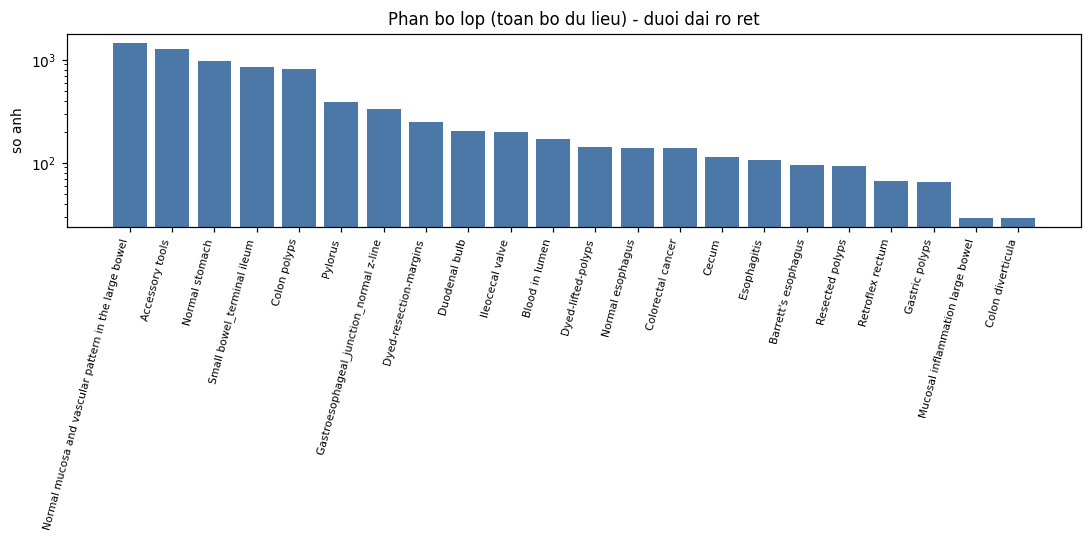

                                                  lop  tong  train  val  test
Normal mucosa and vascular pattern in the large bowel  1467    880  293   294
                                      Accessory tools  1266    760  253   253
                                       Normal stomach   969    581  194   194
                           Small bowel_terminal ileum   846    508  169   169
                                         Colon polyps   820    492  164   164
                                              Pylorus   393    236   78    79
              Gastroesophageal_junction_normal z-line   330    198   66    66
                               Dyed-resection-margins   246    148   49    49
                                        Duodenal bulb   205    123   41    41
                                      Ileocecal valve   200    120   40    40
                                       Blood in lumen   171    103   34    34
                                   Dyed-lifted-polyps   141     

In [9]:
cnt_full = np.bincount(labels, minlength=NUM_CLASSES)
order = np.argsort(-cnt_full)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(NUM_CLASSES), cnt_full[order], color="#4C78A8")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([CLASSES[i] for i in order], rotation=75, ha="right", fontsize=7)
ax.set_ylabel("so anh"); ax.set_title("Phan bo lop (toan bo du lieu) - duoi dai ro ret")
ax.set_yscale("log")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=130); plt.show()

eda = pd.DataFrame({
    "lop": [CLASSES[i] for i in order],
    "tong": cnt_full[order],
    "train": [int((labels[FULL_SPLIT['train']] == i).sum()) for i in order],
    "val":   [int((labels[FULL_SPLIT['val']] == i).sum()) for i in order],
    "test":  [int((labels[FULL_SPLIT['test']] == i).sum()) for i in order],
})
print(eda.to_string(index=False))
print(f"\nTy le mat can bang (lop lon nhat / nho nhat): {cnt_full.max() / cnt_full.min():.1f}x")
print(f"So lop co < 10 anh TEST: {(eda['test'] < 10).sum()} / {NUM_CLASSES}")
print("\n-> Day chinh la ly do macro-F1 rat nhieu: mot lop hiem chi co vai anh test,")
print("   doan dung them 1 anh la F1 cua lop do nhay ~0.15, keo ca trung binh 22 lop.")

---
## 8. Audit rò rỉ dữ liệu giữa 3 tập

Dữ liệu nội soi rất dễ chứa **nhiều khung hình của cùng một ca bệnh**. Nếu hai khung gần như giống nhau
rơi vào train và test thì mọi con số — kể cả 0,6504 của bài báo — đều bị thổi phồng.

Hai lớp kiểm tra:
1. **Trùng byte** — băm MD5 toàn bộ file. Rẻ, chạy trên **toàn bộ** dữ liệu ở mọi hồ sơ.
2. **Gần trùng** — cosine trên embedding của một mạng đã pretrain. Ở `cpu-smoke` giới hạn số ảnh cho nhanh.

Tìm ra rò rỉ → đó là đóng góp mạnh nhất của phần Dữ liệu. Không tìm ra → báo cáo vẫn được quyền viết câu
*"đã kiểm tra rò rỉ, không phát hiện"*, và đó là câu người chấm hỏi đầu tiên.

In [10]:
# --- Lop 1: trung byte (MD5) ---
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()


split_of = {}
for name, ids in FULL_SPLIT.items():
    for i in ids:
        split_of[i] = name

t0 = time.time()
by_hash = collections.defaultdict(list)
for i, (p, y) in enumerate(samples):
    by_hash[md5(p)].append(i)

dup_groups = {h: v for h, v in by_hash.items() if len(v) > 1}
cross = [v for v in dup_groups.values() if len({split_of[i] for i in v}) > 1]
n_dup_imgs = sum(len(v) for v in dup_groups.values())

print(f"MD5 tren {len(samples)} anh trong {time.time() - t0:.0f}s")
print(f"  nhom trung byte          : {len(dup_groups)}  ({n_dup_imgs} anh)")
print(f"  nhom VAT QUA cac tap chia: {len(cross)}   <-- day moi la ro ri that su")
for v in cross[:5]:
    print("   *", [(split_of[i], CLASSES[labels[i]], Path(samples[i][0]).name) for i in v])
MD5_LEAK = len(cross)

MD5 tren 7930 anh trong 4s
  nhom trung byte          : 1  (2 anh)
  nhom VAT QUA cac tap chia: 1   <-- day moi la ro ri that su
   * [('val', 'Colon polyps', 'ba615bcd-2f99-4a12-884d-d9cd2c04c2a1.jpg'), ('train', 'Colon polyps', 'ckda1fpc5000l3a5s17a45xql.jpg')]


In [11]:
# --- Lop 2: gan trung (cosine tren embedding da pretrain) ---
# Dung MobileNetV3-Small: du tot de do "giong nhau", va re gap nhieu lan DenseNet tren CPU.
AUDIT_SIZE, AUDIT_TH = 160, 0.98

_emb_net = tv.models.mobilenet_v3_small(weights=tv.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
_emb_net.classifier = nn.Identity()
_emb_net = _emb_net.eval().to(DEVICE)

_emb_tf = transforms.Compose([
    transforms.Resize((AUDIT_SIZE, AUDIT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

audit_ids = np.arange(len(samples))
if CFG["audit_cap"] and len(audit_ids) > CFG["audit_cap"]:
    audit_ids = np.random.default_rng(0).choice(audit_ids, CFG["audit_cap"], replace=False)
    audit_ids.sort()
    print(f"[{PROFILE}] gioi han audit gan-trung o {len(audit_ids)} anh (chay that se lam toan bo)")


@torch.no_grad()
def embed(ids, bs=64):
    out = []
    for s in range(0, len(ids), bs):
        batch = torch.stack([_emb_tf(Image.open(samples[i][0]).convert("RGB"))
                             for i in ids[s:s + bs]]).to(DEVICE)
        out.append(F.normalize(_emb_net(batch), dim=1).cpu())
    return torch.cat(out)


t0 = time.time()
E = embed(audit_ids)
print(f"embedding {len(audit_ids)} anh trong {time.time() - t0:.0f}s  -> shape {tuple(E.shape)}")

# Nhan ma tran theo khoi de khong no bo nho khi chay toan bo ~8000 anh.
near, BS = [], 512
for s in range(0, len(E), BS):
    sim = E[s:s + BS] @ E.T
    for r in range(sim.shape[0]):
        i_global = s + r
        sim[r, :i_global + 1] = -1                       # chi lay nua tren, bo duong cheo
        hits = torch.nonzero(sim[r] >= AUDIT_TH).flatten().tolist()
        for j in hits:
            a, b = audit_ids[i_global], audit_ids[j]
            if split_of[a] != split_of[b]:
                near.append((a, b, float(sim[r, j])))

print(f"\nCap GAN TRUNG (cosine >= {AUDIT_TH}) nam o HAI tap khac nhau: {len(near)}")
for a, b, s in sorted(near, key=lambda x: -x[2])[:5]:
    print(f"   {s:.4f}  {split_of[a]}/{CLASSES[labels[a]]}/{Path(samples[a][0]).name}"
          f"   <->   {split_of[b]}/{CLASSES[labels[b]]}/{Path(samples[b][0]).name}")

NEAR_LEAK = len(near)

# Dem cap khong chi de bao "co ro ri" ma con de tra loi cau hoi nguoi cham chac chan se hoi:
# ro ri do lam sai lech con so test bao nhieu?
LEAK_TEST_IDS = sorted({i for a, b, _ in near for i in (a, b) if split_of[i] == "test"}
                       | {i for v in cross for i in v if split_of[i] == "test"})
n_test_full = len(FULL_SPLIT["test"])
# Cap gan trung NHUNG KHAC NHAN khong phai ro ri ma la NHIEU NHAN cua bo du lieu: cung mot khung
# hinh duoc gan hai ten benh khac nhau -> khong mo hinh nao co the dung ca hai. Day la mot phat
# hien ve chat luong du lieu, dang mot doan trong bao cao.
mislabel = [(a, b, sc) for a, b, sc in near if labels[a] != labels[b]]

print("\n=== KET LUAN AUDIT ===")
print(f"trung byte vat qua cac tap : {MD5_LEAK}")
print(f"gan trung vat qua cac tap  : {NEAR_LEAK} (nguong {AUDIT_TH}"
      f"{', tren tap con' if CFG['audit_cap'] else ', toan bo du lieu'})")
print(f"anh TEST bi anh huong      : {len(LEAK_TEST_IDS)} / {n_test_full} "
      f"= {100 * len(LEAK_TEST_IDS) / max(1, n_test_full):.2f}%  (muc 19b tinh lai macro-F1 khi bo chung)")
print(f"cap gan trung KHAC NHAN    : {len(mislabel)}  <-- nhieu nhan cua bo du lieu, khong phai ro ri")
for a, b, sc in sorted(mislabel, key=lambda x: -x[2])[:3]:
    print(f"   {sc:.4f}  {CLASSES[labels[a]]} ({split_of[a]})  vs  {CLASSES[labels[b]]} ({split_of[b]})")
del _emb_net

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 73.1MB/s]


embedding 7930 anh trong 78s  -> shape (7930, 576)

Cap GAN TRUNG (cosine >= 0.98) nam o HAI tap khac nhau: 9
   1.0000  val/Colon polyps/ba615bcd-2f99-4a12-884d-d9cd2c04c2a1.jpg   <->   train/Colon polyps/ckda1fpc5000l3a5s17a45xql.jpg
   1.0000  val/Esophagitis/N2DaTmFs.jpg   <->   test/Normal esophagus/WdSYgDiw.jpg
   0.9998  test/Gastroesophageal_junction_normal z-line/02a7a210-f047-4852-94f9-b0d844a131d7.jpg   <->   val/Gastroesophageal_junction_normal z-line/asUGeYOA.jpg
   0.9998  train/Accessory tools/ckcbq0gs703hv0y4h735ha581.jpg   <->   val/Gastric polyps/8f5dae06-df66-49e5-8a07-8447daf122e7.jpg
   0.9995  train/Pylorus/04c2bbc5-1ffe-4014-91bc-eabb9295af48.jpg   <->   test/Pylorus/pT8eFgiY.jpg

=== KET LUAN AUDIT ===
trung byte vat qua cac tap : 1
gan trung vat qua cac tap  : 9 (nguong 0.98, toan bo du lieu)
anh TEST bi anh huong      : 6 / 1586 = 0.38%  (muc 19b tinh lai macro-F1 khi bo chung)
cap gan trung KHAC NHAN    : 2  <-- nhieu nhan cua bo du lieu, khong phai ro ri
   

---
## 9. Dataset, phép biến đổi ảnh và bộ nạp dữ liệu

Augment được chọn **theo miền nội soi**, không phải bê nguyên công thức ImageNet:

* **Lật ngang** — hợp lệ: ảnh nội soi không có chiều trái/phải cố định.
* **Không lật dọc** — nội soi có hướng (trên/dưới), lật dọc tạo ảnh không tồn tại trong thực tế.
* **Xoay ≤ 10°, jitter màu nhẹ** — mô phỏng rung tay và khác biệt nguồn sáng giữa các máy nội soi.
* **Không augment mạnh** (RandAugment, RandomErasing lớn) ở mọi lần chạy trong notebook này. Cấu
  hình duy nhất từng dùng nó — `B2` của vòng thí nghiệm đầu, `RESULTS.md` §6 — tụt **−0,035**, nhưng
  chính `RESULTS.md` quy nguyên nhân cho **công thức bị under-train** (LR backbone thấp gấp 10 lần),
  *không* cho bản thân augment. Vậy câu đúng để viết vào báo cáo là **"chưa đo được lợi ích, và lần
  thử duy nhất bị hỏng vì một lỗi tinh chỉnh"** — không phải *"augment mạnh làm hỏng kết quả"*.
  `train_tf_strong` / `use_aug(True)` vẫn nằm trong code làm định nghĩa của điều kiện đó, nhưng
  **không lần chạy nào ở đây gọi tới**.

In [12]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


def build_transforms(sz):
    plain = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    strong = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(0.15, 0.15, 0.15, 0.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.1),
    ])
    ev = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return plain, strong, ev


train_tf_plain, train_tf_strong, eval_tf = build_transforms(IMG_SIZE)
train_tf = train_tf_plain


def set_img_size(sz):
    '''Doi do phan giai dau vao. make_loaders() doc bien toan cuc luc goi -> goi TRUOC run_seeds.'''
    global IMG_SIZE, train_tf, train_tf_plain, train_tf_strong, eval_tf
    IMG_SIZE = sz
    train_tf_plain, train_tf_strong, eval_tf = build_transforms(sz)
    train_tf = train_tf_plain
    print(f"IMG_SIZE -> {sz} (dung augment 'plain')")


def use_aug(strong=True):
    global train_tf
    train_tf = train_tf_strong if strong else train_tf_plain
    print("augment ->", "strong" if strong else "plain")


class GastroDataset(Dataset):
    def __init__(self, indices, transform):
        self.items = [samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        return self.transform(Image.open(path).convert("RGB")), y


def make_loaders(batch=None):
    '''generator + worker_init_fn: khong co chung thi thu tu tron va RNG cua worker khong bam theo
    seed -> hai lan chay "cung seed" van lech nhau. Nho goi set_seed() truoc.'''
    b = batch or BATCH_SIZE
    common = dict(batch_size=b, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                  worker_init_fn=seed_worker)
    tr = DataLoader(GastroDataset(train_idx, train_tf), shuffle=True, generator=DATA_GEN, **common)
    va = DataLoader(GastroDataset(val_idx, eval_tf), shuffle=False, **common)
    te = DataLoader(GastroDataset(test_idx, eval_tf), shuffle=False, **common)
    return tr, va, te


print("so anh:", len(train_idx), len(val_idx), len(test_idx), "| IMG_SIZE =", IMG_SIZE)

so anh: 4758 1586 1586 | IMG_SIZE = 224


---
## 10. Bộ đánh giá dùng chung

Mọi kiến trúc đều đi qua **đúng những hàm này** — đó là điều khiến so sánh CNN vs Transformer vs Hybrid
có giá trị.

Điểm mấu chốt của thiết kế: `evaluate()` trả về **logits**, không chỉ nhãn dự đoán.
Nhờ đó những thứ sau **không tốn thêm một epoch nào**:

* khoảng tin cậy bootstrap,
* ensemble nhiều checkpoint / nhiều seed / nhiều kiến trúc,
* hiệu chỉnh logit theo tần suất lớp (`logit adjustment`) — dò tham số τ trên tập val,
* đổi quy tắc chọn checkpoint sau khi đã train xong.

In [13]:
ALL_LABELS = list(range(NUM_CLASSES))


def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=ALL_LABELS, average="macro", zero_division=0)


def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


@torch.no_grad()
def evaluate(model, loader, tta=False):
    '''Tra ve macro-F1, micro-F1, nhan that, nhan doan VA logits (float32).'''
    model.eval()
    ys, ls = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            out = model(x).float()
            if tta:                                   # TTA = trung binh voi anh lat ngang
                out = (out + model(torch.flip(x, dims=[3])).float()) / 2
        ls.append(out.cpu().numpy()); ys.append(y.numpy())
    logits = np.concatenate(ls).astype(np.float32)
    y_true = np.concatenate(ys)
    y_pred = logits.argmax(1)
    return dict(macro_f1=macro_f1(y_true, y_pred),
                micro_f1=f1_score(y_true, y_pred, labels=ALL_LABELS, average="micro", zero_division=0),
                y_true=y_true, y_pred=y_pred, logits=logits)


def report_per_class(res, title=""):
    print(f"--- F1 tung lop {title} ---")
    print(classification_report(res["y_true"], res["y_pred"], labels=ALL_LABELS,
                                target_names=CLASSES, zero_division=0, digits=3))


def plot_confusion(res, title="", fname=None):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=ALL_LABELS)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    plt.xlabel("du doan"); plt.ylabel("that"); plt.title(f"Ma tran nham lan {title}")
    plt.xticks(rotation=75, ha="right", fontsize=6); plt.yticks(fontsize=6)
    plt.tight_layout()
    if fname:
        plt.savefig(OUTPUT_DIR / fname, dpi=130)
    plt.show()


def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=0, verbose=True):
    '''Khoang tin cay 95% cho macro-F1 bang cach lay lai mau anh test co hoan lai. 0 epoch.'''
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        # Chi trung binh tren cac lop CO MAT trong mau lay lai. Neu ep labels=ALL_LABELS thi mot lop
        # hiem (~6 anh test) vang mat se bi tinh F1=0 va keo trung binh xuong ~1/22 -- do la loi cua
        # phep lay mau, khong phai cua mo hinh.
        present = np.unique(y_true[i])
        stats.append(f1_score(y_true[i], y_pred[i], labels=present, average="macro", zero_division=0))
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    point = macro_f1(y_true, y_pred)
    if verbose:
        print(f"macro-F1 = {point:.4f}   CI 95% [{lo:.4f}, {hi:.4f}]")
    return dict(point=float(point), lo=float(lo), hi=float(hi))


def ensemble_logits(list_of_logits, weights=None):
    '''Trung binh XAC SUAT (softmax) chu khong phai logits tho: cac kien truc khac nhau co thang
    logit khac nhau, cong thang se de mo hinh "tu tin" nhat lan at.'''
    probs = [softmax_np(l) for l in list_of_logits]
    w = np.ones(len(probs)) if weights is None else np.asarray(weights, dtype=float)
    w = w / w.sum()
    return sum(wi * p for wi, p in zip(w, probs))


def logit_adjust(logits, counts=None, tau=1.0):
    '''Hieu chinh logit theo tan suat lop (Menon et al. 2021): tru di tau*log(prior).
    Ap luc SUY LUAN nen khong ton epoch nao -- doi lap voi Balanced-Softmax (luc huan luyen).'''
    counts = TRAIN_CLASS_COUNTS if counts is None else counts
    prior = np.asarray(counts, dtype=np.float64)
    prior = prior / prior.sum()
    return logits - tau * np.log(prior + 1e-12)[None, :]


def tune_tau(val_logits, val_y, taus=np.arange(0.0, 1.01, 0.1)):
    '''Do tau tren tap VAL (khong bao gio tren test) roi tra ve tau tot nhat.'''
    scores = [(float(t), macro_f1(val_y, logit_adjust(val_logits, tau=t).argmax(1))) for t in taus]
    best = max(scores, key=lambda x: x[1])
    return best[0], scores


print("bo danh gia san sang | so lop =", NUM_CLASSES)

bo danh gia san sang | so lop = 22


---
## 11. Vòng huấn luyện — và cách chống nhiễu khi chọn checkpoint

`train_one` giữ **ba ứng viên checkpoint trong cùng một lần chạy**:

| Quy tắc | Nội dung | Vì sao có mặt |
| --- | --- | --- |
| `best` | trạng thái có val macro-F1 cao nhất | quy tắc cũ, giữ để so sánh |
| `smooth` | trạng thái tại đỉnh của **trung bình trượt 3 epoch** của val | val quá nhỏ nên một đỉnh đơn lẻ thường là may mắn |
| `top3` | **ensemble xác suất của 3 checkpoint val tốt nhất** | giảm phương sai — đúng bệnh của bài này |

Cả ba đều tính được từ **một** lần huấn luyện, nên việc chọn quy tắc nào **không tốn thêm GPU**.
Đây chính là hạng mục 3a + 3b trong Gate 0 của `README.md`.

In [14]:
class Tracker:
    '''Ghi lai lich su val + giu cac trang thai can thiet cho 3 quy tac chon checkpoint.'''

    def __init__(self, keep_top_k=KEEP_TOP_K, smooth_win=SMOOTH_WIN):
        self.keep_top_k, self.smooth_win = keep_top_k, smooth_win
        self.history, self.top = [], []
        self.smooth = (-1.0, -1, None)

    def update(self, model, vf1, ep):
        self.history.append(float(vf1))
        state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        self.top.append((float(vf1), ep, state))
        self.top.sort(key=lambda t: -t[0])
        del self.top[self.keep_top_k:]
        sm = float(np.mean(self.history[-self.smooth_win:]))
        if sm > self.smooth[0]:
            self.smooth = (sm, ep, state)

    def finalize(self, model):
        model.load_state_dict(self.top[0][2])
        return dict(best_val=self.top[0][0], best_epoch=self.top[0][1],
                    history=self.history, top=self.top, smooth=self.smooth)


def train_one(model, tr, va, epochs=None, lr=1e-4, criterion=None, class_weights=None,
              freeze_bn=False, verbose=True):
    '''Fine-tune don gian (AdamW + AMP). Day la cong thuc chuan cua ca 4 cau hinh chinh
    (B0/S0/P0/P1); so cu the xem bang o muc 16 va 19.
    freeze_bn=True: moi lop BatchNorm nam trong phan DA DONG BANG duoc dua ve che do eval
    (chi can khi lam linear probe / dong bang mot phan -- xem _freeze_bn_of_frozen_part).'''
    epochs = epochs or EPOCHS
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(weight=class_weights)
    # Loc theo requires_grad: khi backbone bi dong bang thi AdamW khong nen giu state cho chung.
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    tk, dt = Tracker(), float("nan")
    for ep in range(epochs):
        model.train()
        if freeze_bn:
            _freeze_bn_of_frozen_part(model)
        t0 = time.time()
        for x, y in tr:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        dt = time.time() - t0
        vf1 = evaluate(model, va)["macro_f1"]
        tk.update(model, vf1, ep)
        if verbose:
            print(f"  ep {ep + 1:02d}/{epochs}  val_macroF1={vf1:.4f}  "
                  f"(best={tk.top[0][0]:.4f})  {dt:.0f}s/epoch")
    out = tk.finalize(model)
    out["sec_per_epoch"] = dt
    return out


def _head_attr(model):
    for a in ("fc", "classifier", "head"):
        if hasattr(model, a):
            return a
    raise AttributeError("khong tim thay lop phan loai cuoi cung")


def train_advanced(model, tr, va, criterion=None, probe_epochs=3, epochs=None, base_lr=1e-4,
                   backbone_mult=0.5, weight_decay=1e-4, warmup_epochs=2, label_smoothing=0.05,
                   verbose=True):
    '''Cong thuc 2 giai doan: linear probe -> fine-tune toan mang, LR phan biet + cosine warmup.
    LUU Y: da do va THUA baseline don gian (B2 = -0,035) khi backbone_mult=0.1. Giu lai de lam
    phan "transfer learning" cua bao cao, khong phai de chay mac dinh.'''
    epochs = epochs or EPOCHS
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    head = _head_attr(model)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    tk = Tracker()

    def run(opt, sched, n, name, ep0):
        for ep in range(n):
            model.train()
            # Khong lam gi khi ca mang deu trainable (giai doan ft); chi co tac dung o giai doan
            # probe, luc backbone dang bi dong bang -> giu BatchNorm khong troi theo du lieu moi.
            _freeze_bn_of_frozen_part(model)
            for x, y in tr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                    loss = crit(model(x), y)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            if sched is not None:
                sched.step()
            vf1 = evaluate(model, va)["macro_f1"]
            tk.update(model, vf1, ep0 + ep)
            if verbose:
                print(f"  {name} ep {ep + 1:02d}/{n}  val_macroF1={vf1:.4f}  (best={tk.top[0][0]:.4f})")

    if probe_epochs > 0:
        for p in model.parameters():
            p.requires_grad = False
        for p in getattr(model, head).parameters():
            p.requires_grad = True
        opt = torch.optim.AdamW(getattr(model, head).parameters(), lr=1e-3, weight_decay=weight_decay)
        run(opt, None, probe_epochs, "probe", 0)
        for p in model.parameters():
            p.requires_grad = True

    head_params = set(getattr(model, head).parameters())
    backbone = [p for p in model.parameters() if p not in head_params]
    opt = torch.optim.AdamW([{"params": backbone, "lr": base_lr * backbone_mult},
                             {"params": list(head_params), "lr": base_lr}], weight_decay=weight_decay)

    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / max(1, warmup_epochs)
        p = (ep - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * p))

    run(opt, torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda), epochs, "ft", probe_epochs)
    out = tk.finalize(model)
    out["sec_per_epoch"] = float("nan")
    return out


# ==================== Transfer learning: freeze vs trainable ====================
# Muc 6 cua rubric trong de bai (10%) doi dung mot BANG SO SANH giua cac muc do dong bang.
# Ba ham duoi day tao ra ba dieu kien; dieu kien thu tu (fine-tune toan mang) chinh la B0.


def _freeze_bn_of_frozen_part(model):
    '''Dua moi lop BatchNorm nam trong phan da dong bang ve che do eval.

    Khong lam buoc nay thi 'linear probe' van chua thuc su dong bang: model.train() de BatchNorm
    tiep tuc cap nhat running mean/var theo du lieu noi soi, nen dac trung van dich chuyen qua tung
    epoch du khong co gradient nao chay vao backbone. Voi DenseNet-121 (dac ~120 lop BN) sai lech
    nay khong nho, va no lam mo dung thu ma muc nay muon do.
    '''
    n = 0
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            own = list(m.parameters(recurse=False))
            if own and all(not p.requires_grad for p in own):
                m.eval(); n += 1
    return n


def freeze_backbone(model, frac=1.0):
    '''Dong bang `frac` dau tien cua backbone (theo thu tu named_parameters, tuc theo do sau).

    frac=1.0 -> dong bang toan bo backbone (linear probe). frac=0.5 -> dong bang nua duoi.
    Lop phan loai cuoi LUON duoc hoc. Tra ve (so tham so hoc duoc, tong so tham so).
    LUU Y: thu tu named_parameters chi XAP XI thu tu do sau -- dung duoc cho DenseNet/timm o day,
    nhung day la mot xap xi va phai noi ro trong bao cao.
    '''
    head = _head_attr(model)
    head_ids = {id(p) for p in getattr(model, head).parameters()}
    body = [p for p in model.parameters() if id(p) not in head_ids]
    cut = int(round(len(body) * frac))
    for i, p in enumerate(body):
        p.requires_grad = i >= cut
    for p in getattr(model, head).parameters():
        p.requires_grad = True
    train_n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_n = sum(p.numel() for p in model.parameters())
    print(f"  dong bang {cut}/{len(body)} tensor cua backbone -> hoc "
          f"{train_n / 1e6:.2f}M / {total_n / 1e6:.2f}M tham so ({100 * train_n / total_n:.1f}%)")
    return train_n, total_n


def train_linear_probe(model, tr, va, lr=1e-3, **kw):
    '''T1 -- linear probe: dong bang TOAN BO backbone, chi hoc lop phan loai.

    LR cao hon (1e-3 thay vi 1e-4) vi chi con mot lop linear phai hoc; dung 1e-4 o day la
    tu lam yeu dieu kien nay roi so sanh khong cong bang.
    '''
    freeze_backbone(model, frac=1.0)
    return train_one(model, tr, va, lr=lr, freeze_bn=True, **kw)


def train_partial_unfreeze(model, tr, va, frac=0.5, lr=1e-4, **kw):
    '''T2 -- dong bang mot phan: giu nua duoi backbone, mo nua tren + lop phan loai.'''
    freeze_backbone(model, frac=frac)
    return train_one(model, tr, va, lr=lr, freeze_bn=True, **kw)


class BalancedSoftmaxLoss(nn.Module):
    '''Balanced Softmax (Ren et al. 2020): cong log(tan suat lop) vao logit luc HUAN LUYEN.
    DA DO TREN GASTROVISION: -0,007 so voi baseline -> phang. Giu lai lam ket qua am trong bao cao.'''

    def __init__(self, class_counts, label_smoothing=0.0):
        super().__init__()
        p = torch.tensor(np.asarray(class_counts, dtype=np.float32))
        self.register_buffer("log_prior", torch.log(p / p.sum() + 1e-12))
        self.ls = label_smoothing

    def forward(self, logits, target):
        return F.cross_entropy(logits + self.log_prior.to(logits.device), target,
                               label_smoothing=self.ls)


print("ham huan luyen san sang")

ham huan luyen san sang


---
## 12. Ba kiến trúc

| Vai trò | Mô hình | Nguồn trọng số | Yêu cầu đặt **trước** khi chạy |
| --- | --- | --- | --- |
| **Baseline tham chiếu** (bắt buộc) | DenseNet-121 | torchvision `IMAGENET1K_V1` | khớp **0,6504** của bài báo |
| **Baseline mới** (đóng góp của nhóm) | Swin-T | `timm` `swin_tiny_patch4_window7_224.ms_in1k` | bài báo không có số — "tái lập" nghĩa là **train đúng giao thức** |
| **Mô hình đề xuất** | CoAtNet-0 | `timm` `coatnet_0_rw_224.sw_in1k` | phải vượt **cả hai** dòng trên |

⚠️ **Cột cuối là kỳ vọng, không phải kết quả — và vòng A100 chỉ đạt một phần.** Đọc bảng này rồi nhảy
xuống bảng số là rất dễ tưởng cả ba yêu cầu đã đạt. Thực tế:

* DenseNet-121 **tái lập được**: 0,6491 ± 0,0124 dưới quy tắc `best`, so với 0,6504 của bài báo.
* CoAtNet-0 **không** vượt Swin-T ở cùng 224: `P0` = 0,6818 so với `S0` = 0,6851 (quy tắc `top3_tta`).
  Chỉ khi thêm đòn bẩy độ phân giải thì `P1` @288 = 0,6961 mới đứng trên cả hai baseline.
* Và ngay cả `P1` cũng **không tách được** khỏi hai baseline về mặt thống kê ở 3 seed — CI bootstrap
  chồng lấn. Mục 21 mổ xẻ đúng chỗ này; đó là kết quả âm phải viết vào báo cáo, không phải chỗ để
  làm tròn lên.

**Swin-T dùng trọng số ImageNet-1k, không dùng in22k** ở dòng baseline: DenseNet-121 cũng là in1k,
đổi sang in22k là phá vỡ thế cân bằng khiến phép so sánh CNN vs Transformer mất giá trị.
Trọng số in22k được để dành làm **một dòng ablation riêng** (mục 19c) — ⚠️ ablation đó **mặc định
tắt và chưa từng chạy** trong bản notebook này, nên đừng đi tìm con số in22k ở phía dưới.

`check_forward()` chạy một lượt truyền xuôi giả trước khi huấn luyện — nếu một mô hình `timm`
không nhận độ phân giải hiện tại thì hỏng **ngay lập tức với thông báo rõ ràng**, thay vì hỏng
sau 20 phút huấn luyện trên Colab.

In [15]:
def build_densenet121(nc):
    m = tv.models.densenet121(weights=tv.models.DenseNet121_Weights.IMAGENET1K_V1)
    m.classifier = nn.Linear(m.classifier.in_features, nc)
    return m.to(DEVICE)


def _timm_build(name, nc):
    assert timm is not None, "can cai timm: pip install timm"
    kw = dict(pretrained=True, num_classes=nc)
    if IMG_SIZE != 224:
        try:
            return timm.create_model(name, img_size=IMG_SIZE, **kw).to(DEVICE)
        except Exception as e:
            print(f"[{name}] khong nhan img_size={IMG_SIZE} ({type(e).__name__}) -> dung 224")
    return timm.create_model(name, **kw).to(DEVICE)


def build_swin_t(nc):        return _timm_build("swin_tiny_patch4_window7_224.ms_in1k", nc)
def build_swin_t_in22k(nc):  return _timm_build("swin_tiny_patch4_window7_224.ms_in22k_ft_in1k", nc)
def build_coatnet0(nc):      return _timm_build("coatnet_0_rw_224.sw_in1k", nc)


def check_forward(model, name=""):
    '''Kiem tra shape truoc khi ton mot epoch nao.'''
    model.eval()
    with torch.no_grad():
        out = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
    assert out.shape == (2, NUM_CLASSES), \
        f"{name}: dau ra {tuple(out.shape)} != (2, {NUM_CLASSES}) o do phan giai {IMG_SIZE}"
    n_par = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {name:12s} OK | {n_par:5.1f}M tham so | dau vao {IMG_SIZE}x{IMG_SIZE}")
    return n_par


BUILDERS = {"densenet121": build_densenet121}
if timm is not None:
    BUILDERS.update({"swin_t": build_swin_t, "coatnet0": build_coatnet0})

PARAM_COUNTS = {}
for _k, _f in BUILDERS.items():
    _m = _f(NUM_CLASSES)
    PARAM_COUNTS[_k] = check_forward(_m, _k)
    del _m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 173MB/s]


  densenet121  OK |   7.0M tham so | dau vao 224x224


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

  swin_t       OK |  27.5M tham so | dau vao 224x224


model.safetensors: reconstructing file:   0%|          |  0.00B /  110MB            

model.safetensors: downloading bytes:           |  0.00B            

  coatnet0     OK |  26.7M tham so | dau vao 224x224


---
## 13. Bộ chạy đa seed — một lần huấn luyện, sáu con số

`run_seeds` là **cửa duy nhất** dẫn tới GPU. Mỗi seed huấn luyện **một lần** rồi rút ra
**3 quy tắc chọn checkpoint × 2 chế độ (có/không TTA) = 6 điểm số**, và ghi ra đĩa:

* `logits` của tập test cho từng quy tắc → mọi phân tích về sau đều 0 epoch,
* `logits` của tập **val** → để dò tham số τ mà không bao giờ chạm vào test,
* lịch sử val từng epoch → vẽ đường học, chẩn đoán overfit,
* thời gian huấn luyện thực đo → dùng để lập ngân sách cho Colab.

**Tự khôi phục:** nếu file `.npz` của một seed đã tồn tại thì seed đó **không train lại**.
Colab rớt mạng giữa chừng → chạy lại `Run all` là tiếp tục từ chỗ dở, không mất giờ GPU nào.
Đặt `FORCE_RERUN = True` nếu muốn huấn luyện lại từ đầu.

> ⚠️ **Vì sao bản notebook bạn đang đọc không có log của một lần huấn luyện chính nào.** Mọi ô ở mục
> 15, 15b và 19d đều in `doc lai tu ..._seed*.npz (bo qua huan luyen)`: đây là **lần chạy A100 thứ tư**,
> và toàn bộ các lần huấn luyện chính được nạp lại từ Drive thay vì train lại. Số trong output là số
> thật của những lần train trước đó, **không phải** số của một lần chạy rỗng. Nhật ký của các vòng
> train gốc nằm ở `RESULTS.md` §9.
>
> Ngoại lệ duy nhất là **Gate 0a ở mục 14** — nó *có* train thật 2 × 3 epoch, vì phép kiểm tất định
> không có gì để nạp lại.

In [16]:
SELECTION_RULE = "best"     # gia tri khoi dau; MUC 16 do ca 6 cot (3 quy tac x 2 che do TTA) roi chot lai
FORCE_RERUN    = False      # True = train lai ke ca da co ket qua luu tren dia
RESULTS_STORE  = {}         # tag -> ket qua tong hop


def _npz(tag, seed):
    return CKPT_DIR / f"{tag}_seed{seed}.npz"


def run_seeds(build_fn, tag, seeds=None, train_fn=train_one, post_fn=None, resume=True, **train_kw):
    seeds = SEEDS if seeds is None else seeds
    per_seed = []

    for s in seeds:
        path = _npz(tag, s)
        if resume and path.exists() and not FORCE_RERUN:
            d = np.load(path, allow_pickle=True)
            sc = json.loads(str(d["scores_json"]))
            print(f"[{tag} seed {s}] doc lai tu {path.name} (bo qua huan luyen)")
        else:
            set_seed(s)
            tr, va, te = make_loaders()
            model = build_fn(NUM_CLASSES)
            check_forward(model, tag)
            print(f"[{tag} seed {s}] bat dau huan luyen ({EPOCHS} epoch, batch {BATCH_SIZE})")
            t0 = time.time()
            r = train_fn(model, tr, va, **train_kw)
            train_sec = time.time() - t0
            if post_fn is not None:
                post_fn(model)

            # Ung vien checkpoint: top-K theo val, cong them trang thai "smooth" neu no khong nam trong top-K
            cand = list(r["top"])
            smooth_state = r["smooth"][2]
            smooth_i = next((i for i, (_, _, st) in enumerate(cand) if st is smooth_state), None)
            if smooth_i is None:
                cand.append((r["smooth"][0], r["smooth"][1], smooth_state))
                smooth_i = len(cand) - 1

            L, y_true = {}, None
            for i, (_, _, st) in enumerate(cand):
                model.load_state_dict(st)
                for tta in (False, True):
                    e = evaluate(model, te, tta=tta)
                    L[(i, tta)] = e["logits"]
                    y_true = e["y_true"]

            # logits tren VAL cua checkpoint chinh -> dung de do tau (khong bao gio do tren test)
            model.load_state_dict(cand[0][2])
            ev = evaluate(model, va)
            n_top = min(KEEP_TOP_K, len(r["top"]))

            sc, store = {}, {}
            for tta in (False, True):
                sfx = "_tta" if tta else ""
                ens = ensemble_logits([L[(i, tta)] for i in range(n_top)])
                store[f"logits_best{sfx}"] = L[(0, tta)]
                store[f"logits_smooth{sfx}"] = L[(smooth_i, tta)]
                store[f"probs_top{n_top}{sfx}"] = ens
                sc[f"best{sfx}"]   = macro_f1(y_true, L[(0, tta)].argmax(1))
                sc[f"smooth{sfx}"] = macro_f1(y_true, L[(smooth_i, tta)].argmax(1))
                sc[f"top3{sfx}"]   = macro_f1(y_true, ens.argmax(1))

            sc["best_val"] = r["best_val"]
            sc["train_sec"] = train_sec
            sc["sec_per_epoch"] = r.get("sec_per_epoch", float("nan"))

            np.savez_compressed(
                path, y_true=y_true, val_y=ev["y_true"], val_logits=ev["logits"],
                history=np.array(r["history"], dtype=np.float32),
                scores_json=json.dumps(sc), **store)
            torch.save(cand[0][2], CKPT_DIR / f"{tag}_seed{s}.pt")
            print(f"[{tag} seed {s}] xong sau {train_sec / 60:.1f} phut -> {path.name}")

        per_seed.append(sc)
        print("   " + "  ".join(f"{k}={sc[k]:.4f}" for k in
                                ("best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta")))

    rules = ["best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta"]
    agg = {r: (float(np.mean([d[r] for d in per_seed])), float(np.std([d[r] for d in per_seed])))
           for r in rules}
    RESULTS_STORE[tag] = dict(tag=tag, seeds=list(seeds), per_seed=per_seed, agg=agg)
    m, sd = agg[SELECTION_RULE]
    print(f"\n>>> {tag}  TEST macro-F1 (quy tac '{SELECTION_RULE}') = {m:.4f} +/- {sd:.4f}"
          f"   tren {len(seeds)} seed")
    if IS_SMOKE:
        print("    (che do cpu-smoke: con so nay chi de chung minh code chay, khong co y nghia)")
    return RESULTS_STORE[tag]


def load_run(tag, seed):
    d = np.load(_npz(tag, seed), allow_pickle=True)
    out = {k: d[k] for k in d.files if k != "scores_json"}
    out["scores"] = json.loads(str(d["scores_json"]))
    return out


# Ten mang luu tren dia KHONG trung ten quy tac: quy tac "top3" nam duoi khoa "probs_top3" (la
# XAC SUAT da trung binh) chu khong phai "logits_top3". Ep hai the gioi nay khop nhau o dung mot
# cho, neu khong moi o phan tich phia sau se lang le doc nham ve logits_best.
RULE_KEY = {"best": "logits_best",     "best_tta": "logits_best_tta",
            "smooth": "logits_smooth", "smooth_tta": "logits_smooth_tta",
            "top3": "probs_top3",      "top3_tta": "probs_top3_tta"}


def _top_key(d, tta):
    '''Khoa cua ensemble checkpoint mang so luong THUC TE giu duoc: chay 30 epoch thi la
    "probs_top3", nhung ho so cpu-smoke chi co 2 epoch nen chi la "probs_top2". Do tim thay vi
    viet cung "top3" -> mot file .npz cu hay mot lan chay ngan deu khong lam vo phan phan tich.'''
    for k in d:
        if k.startswith("probs_top") and k.endswith("_tta") == tta:
            return k
    return None


def sel_scores(d, rule=None):
    '''Diem so tren tap test ung voi quy tac chon checkpoint dang dung.
    Thieu khoa thi BAO LOI TO, tuyet doi khong am tham quay ve logits_best.'''
    rule = rule or SELECTION_RULE
    key = RULE_KEY[rule]
    if key not in d and key.startswith("probs_top"):
        key = _top_key(d, rule.endswith("_tta")) or key
    if key not in d:
        raise KeyError(f"file .npz thieu '{key}' (quy tac '{rule}'). "
                       "File ghi boi phien ban cu -> chay lai voi FORCE_RERUN = True.")
    return d[key]


def as_logits(a):
    '''probs_top3 la xac suat (moi hang tong = 1), khong phai logit. Muon tru log-prior hay dem
    di ensemble tiep thi phai lay log truoc -- softmax(log p) = p nen phep nay khong lam meo gi.'''
    a = np.asarray(a, dtype=np.float64)
    if a.min() >= 0 and np.allclose(a.sum(axis=1), 1.0, atol=1e-3):
        return np.log(a + 1e-12)
    return a


print("run_seeds san sang | thu muc luu:", CKPT_DIR)

run_seeds san sang | thu muc luu: /content/drive/MyDrive/gastrovision_ckpts


---
## 14. Gate 0a — kiểm tra tính tất định

Hai lần chạy `B0` **cũ** — vòng thí nghiệm đầu, **không** phải `B0_densenet121` của notebook này (xem
cảnh báo về hệ mã ở mục 2) — **cùng seed** từng lệch nhau 0,024 macro-F1. Phương sai giữa các seed
**không** giải thích được điều đó, nên chỉ còn hai khả năng: hai lần chạy thực ra khác cấu hình, hoặc
pipeline **thực sự bất định** (AMP + kernel CUDA không có bản cài đặt tất định + DataLoader chưa gieo hạt).

Phép kiểm rẻ và dứt khoát: chạy **cùng một cấu hình hai lần, chỉ 3 epoch**, rồi so **toàn bộ đường val** —
chứ không chỉ so con số cuối. Nếu hai đường trùng khít từng epoch thì pipeline là tất định **trên đúng
GPU đó**, và ta được quyền gọi mọi chênh lệch còn lại là phương sai giữa các seed.

> ⚠️ **"Tất định" ở đây chỉ đúng trong phạm vi MỘT loại GPU.** Phép kiểm này đã chạy ba lần và cho
> một kết luận không nằm trong kế hoạch ban đầu: trên A100 hai lần đều ra
> `[0.428608, 0.549646, 0.551532]` (và lần chạy thứ tư lặp lại y hệt), nhưng **cùng seed, cùng code,
> trên T4 lại ra `[0.430615, 0.540379, 0.541930]`**. Cùng một hạt giống + cùng một đoạn code + GPU
> khác = **một mô hình khác**.
>
> Hệ quả bắt buộc phải tuân: **không được trộn phần cứng trong cùng một σ.** Cả 12 lần chạy chính của
> notebook này đều trên A100 vì lý do đó; nếu sau này thêm seed trên GPU khác thì phương sai phần cứng
> sẽ lẫn vào σ và phải khai báo rõ. Chi tiết ở `RESULTS.md` §3 (Gate 0a).

In [17]:
RUN_DETERMINISM_CHECK = True   # ~3 epoch x 2 lan; tren T4 khoang 5-7 phut
DET_EPOCHS = 3

if RUN_DETERMINISM_CHECK:
    curves = []
    for rep in range(2):
        set_seed(0)
        tr, va, _ = make_loaders()
        m = build_densenet121(NUM_CLASSES)
        r = train_one(m, tr, va, epochs=DET_EPOCHS, verbose=False)
        curves.append([round(v, 6) for v in r["history"]])
        print(f"lan {rep + 1}: val macro-F1 tung epoch = {curves[-1]}")
        del m
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    same = curves[0] == curves[1]
    print("\n=== KET QUA GATE 0a ===")
    print("hai duong val TRUNG KHIT" if same else "hai duong val KHAC NHAU")
    if same:
        print("-> pipeline tat dinh o cung seed. Moi chenh lech con lai la phuong sai GIUA CAC SEED,")
        print("   va trung binh 3 seed la cach do dung.")
        if DEVICE == "cpu":
            print("")
            print("   !! Phep kiem nay vua chay tren CPU nen CHUA ket luan duoc gi ve GPU:")
            print("      AMP va cac kernel cuDNN la nguon bat dinh HOAN TOAN KHAC.")
            print("      Phai chay lai chinh o nay tren Colab truoc khi tin so do GPU.")
    else:
        d = max(abs(a - b) for a, b in zip(*curves))
        print(f"-> con bat dinh, lech toi da {d:.4f} moi epoch. Doc lai canh bao cua")
        print("   use_deterministic_algorithms o tren: do la danh sach op chua co ban tat dinh.")
        print("   Khi do phai bao cao trung binh nhieu lan chay, khong duoc trich mot lan chay.")
else:
    print("bo qua Gate 0a (dat RUN_DETERMINISM_CHECK = True de chay)")

lan 1: val macro-F1 tung epoch = [0.428608, 0.549646, 0.551532]
lan 2: val macro-F1 tung epoch = [0.428608, 0.549646, 0.551532]

=== KET QUA GATE 0a ===
hai duong val TRUNG KHIT
-> pipeline tat dinh o cung seed. Moi chenh lech con lai la phuong sai GIUA CAC SEED,
   va trung binh 3 seed la cach do dung.


---
## 15. Ba thí nghiệm ở 224 — **hai baseline + một hybrid**

Chạy theo đúng **một giao thức**: cùng tập chia, cùng seed, cùng số epoch, cùng bộ tối ưu, cùng
224×224, cùng augment. Sự công bằng đó mới là thứ làm cho so sánh CNN vs Transformer vs Hybrid
có ý nghĩa — không phải việc mô hình nào được tinh chỉnh kỹ hơn.

| Mã | Mô hình | Vai trò | Baseline? |
| --- | --- | --- | --- |
| `B0` | DenseNet-121 @224 | baseline tham chiếu — phải khớp 0,6504 | ✅ |
| `S0` | Swin-T @224 | baseline mới (Transformer) | ✅ |
| `P0` | CoAtNet-0 @224 | hybrid ở **cùng độ phân giải** — đây là dòng so sánh *thuần kiến trúc* | ❌ |

⚠️ **`P0` chưa phải mô hình đề xuất.** Mô hình đề xuất là `P1` ở mục 15b (CoAtNet-0 @288 + TTA +
ensemble top-3 checkpoint). `P0` tồn tại để phép so `P0` → `P1` chỉ đổi **đúng một thứ** là độ
phân giải; không có nó thì đòn bẩy 288 không tách được khỏi đòn bẩy kiến trúc.

**Đo thật trên A100: ~9,5–10,5 phút/seed**, tức cả **bốn** cấu hình × 3 seed gọn trong ~2 giờ
(bảng phân phiên ở mục 21). Nhờ cơ chế tự khôi phục, vẫn có thể chia thành nhiều phiên Colab.

In [18]:
set_img_size(224)
use_aug(False)

res_b0 = run_seeds(build_densenet121, tag="B0_densenet121")

IMG_SIZE -> 224 (dung augment 'plain')
augment -> plain
[B0_densenet121 seed 0] doc lai tu B0_densenet121_seed0.npz (bo qua huan luyen)
   best=0.6666  best_tta=0.6616  smooth=0.6666  smooth_tta=0.6616  top3=0.6854  top3_tta=0.6768
[B0_densenet121 seed 1] doc lai tu B0_densenet121_seed1.npz (bo qua huan luyen)
   best=0.6394  best_tta=0.6370  smooth=0.6322  smooth_tta=0.6421  top3=0.6624  top3_tta=0.6637
[B0_densenet121 seed 2] doc lai tu B0_densenet121_seed2.npz (bo qua huan luyen)
   best=0.6414  best_tta=0.6342  smooth=0.6424  smooth_tta=0.6333  top3=0.6653  top3_tta=0.6623

>>> B0_densenet121  TEST macro-F1 (quy tac 'best') = 0.6491 +/- 0.0124   tren 3 seed


In [19]:
res_s0 = run_seeds(build_swin_t, tag="S0_swin_t") if timm is not None else None

[S0_swin_t seed 0] doc lai tu S0_swin_t_seed0.npz (bo qua huan luyen)
   best=0.6554  best_tta=0.6605  smooth=0.6593  smooth_tta=0.6629  top3=0.6995  top3_tta=0.6976
[S0_swin_t seed 1] doc lai tu S0_swin_t_seed1.npz (bo qua huan luyen)
   best=0.6611  best_tta=0.6539  smooth=0.6860  smooth_tta=0.6885  top3=0.6777  top3_tta=0.6878
[S0_swin_t seed 2] doc lai tu S0_swin_t_seed2.npz (bo qua huan luyen)
   best=0.6476  best_tta=0.6478  smooth=0.6404  smooth_tta=0.6598  top3=0.6830  top3_tta=0.6700

>>> S0_swin_t  TEST macro-F1 (quy tac 'best') = 0.6547 +/- 0.0056   tren 3 seed


In [20]:
res_p0 = run_seeds(build_coatnet0, tag="P0_coatnet0") if timm is not None else None

[P0_coatnet0 seed 0] doc lai tu P0_coatnet0_seed0.npz (bo qua huan luyen)
   best=0.6407  best_tta=0.6570  smooth=0.6426  smooth_tta=0.6574  top3=0.6886  top3_tta=0.6805
[P0_coatnet0 seed 1] doc lai tu P0_coatnet0_seed1.npz (bo qua huan luyen)
   best=0.6649  best_tta=0.6711  smooth=0.6649  smooth_tta=0.6711  top3=0.6820  top3_tta=0.6837
[P0_coatnet0 seed 2] doc lai tu P0_coatnet0_seed2.npz (bo qua huan luyen)
   best=0.6559  best_tta=0.6614  smooth=0.6148  smooth_tta=0.6029  top3=0.6712  top3_tta=0.6812

>>> P0_coatnet0  TEST macro-F1 (quy tac 'best') = 0.6538 +/- 0.0100   tren 3 seed


---
## 15b. Đòn bẩy độ phân giải và **mô hình đề xuất dạng hệ thống**

Vòng thí nghiệm trước cho thấy độ phân giải là đòn bẩy có tín hiệu mạnh nhất trên tập val
(DenseNet-121 @288 đạt val 0,689 — cao nhất trong mọi bậc), dù test khi đó thấp vì nhiễu.

**Ở vòng chạy này chỉ CoAtNet-0 thực sự được chạy ở 288** — vì đó là backbone của mô hình đề xuất, và
mục đích là cô lập đòn bẩy độ phân giải trên đúng một backbone thay vì nhân ba chi phí GPU. Về nguyên
tắc cả ba kiến trúc đều nhận được 288×288 (`timm` nội suy bảng vị trí tương đối cho Swin/CoAtNet), nên
đòn bẩy này không riêng gì DenseNet — *nhưng đó là suy luận, chưa phải phép đo, và đừng trích nó như
một điều đã kiểm chứng cho cả ba.* Chỉ CoAtNet-0 từng đi qua `check_forward` ở 288; hơn nữa
`_timm_build` có nhánh `try/except` **in cảnh báo rồi quay về 224** nếu model từ chối `img_size`, nên
một cấu hình 288 hỏng vẫn chạy tiếp ở 224 — phải đọc dòng `IMG_SIZE -> ...` trong output để biết độ
phân giải thật sự đã dùng.

**Mô hình đề xuất không phải là một kiến trúc, mà là một hệ thống:**

> CoAtNet-0 @ 288 + TTA lật ngang + ensemble top-3 checkpoint

Lý do nói thẳng trong báo cáo: CoAtNet-0 và Swin-T chênh nhau ~1 điểm ImageNet, nhỏ hơn nhiễu
của phép đo này (±0,02–0,05), nên **đặt toàn bộ luận điểm cải tiến lên một lần đổi kiến trúc là
một canh bạc**. Ba thành phần trên tấn công đúng hai bệnh đã chẩn đoán được: biểu diễn đặc trưng
yếu (backbone + độ phân giải) và phương sai do lớp hiếm (TTA + ensemble).

Vì vậy báo cáo phải có **hai** bảng, không được trộn:

| Bảng | So cái gì | Dùng để |
| --- | --- | --- |
| **a. Thuần kiến trúc** | B0 vs S0 vs P0, đều 224 | so sánh CNN / Transformer / Hybrid công bằng tuyệt đối |
| **b. Hệ thống** | P1 (đề xuất đầy đủ) vs hai baseline | nơi đặt tuyên bố vượt 0,6504 |

> Cả hai bảng phải đọc dưới **cùng một** quy tắc chọn checkpoint — quy tắc được chốt ở mục 16 và
> áp cho mọi dòng phía sau. **Trộn hai quy tắc trong một phép so là lỗi rất dễ mắc**, và nó dẫn
> thẳng tới một kết luận sai về đòn bẩy kiến trúc (mục 21 mổ xẻ đúng ca đó); bảng ở mục 16 in ra cả
> sáu cột chính là để phép so nào cũng có thể đọc trong cùng một cột.

⚠️ **Chi phí:** 288×288 có ~1,65× số pixel của 224. **Đo thật:** ~10,5 phút/seed trên A100 (so với
~9,5 của `P0`), và ở lúc suy luận batch 32 thì đúng **1,68×** ms/ảnh — khớp tỉ lệ pixel (mục 20).
Đặt `RUN_P1_288 = False` nếu phiên Colab không đủ giờ; khi đó dùng `P0` + TTA + top-3 làm mô hình
đề xuất rút gọn và ghi rõ trong báo cáo là đã cắt đòn bẩy độ phân giải.

In [21]:
RUN_P1_288 = True     # False = bo qua don bay do phan giai (tiet kiem ~2 gio T4)

if RUN_P1_288 and timm is not None:
    set_img_size(288)
    use_aug(False)
    res_p1 = run_seeds(build_coatnet0, tag="P1_coatnet0_288")
    set_img_size(224)          # tra ve mac dinh cho cac o phia sau
else:
    res_p1 = None
    print("bo qua P1 (do phan giai 288)")

IMG_SIZE -> 288 (dung augment 'plain')
augment -> plain
[P1_coatnet0_288 seed 0] doc lai tu P1_coatnet0_288_seed0.npz (bo qua huan luyen)
   best=0.6768  best_tta=0.6866  smooth=0.6884  smooth_tta=0.6946  top3=0.6802  top3_tta=0.6941
[P1_coatnet0_288 seed 1] doc lai tu P1_coatnet0_288_seed1.npz (bo qua huan luyen)
   best=0.6609  best_tta=0.6649  smooth=0.6644  smooth_tta=0.6672  top3=0.7045  top3_tta=0.6980
[P1_coatnet0_288 seed 2] doc lai tu P1_coatnet0_288_seed2.npz (bo qua huan luyen)
   best=0.6556  best_tta=0.6680  smooth=0.6592  smooth_tta=0.6584  top3=0.6869  top3_tta=0.6961

>>> P1_coatnet0_288  TEST macro-F1 (quy tac 'best') = 0.6645 +/- 0.0090   tren 3 seed
IMG_SIZE -> 224 (dung augment 'plain')


---
## 16. Gate 0 (3b) — chọn quy tắc checkpoint, rồi gắn thanh sai số

**3 quy tắc × 2 chế độ TTA = 6 cột**, tất cả đều đã được tính từ **cùng những lần chạy ở trên**,
nên bảng dưới đây không tốn thêm GPU.
Quy tắc thắng sẽ được dùng cho **mọi** con số trong báo cáo — và phải chọn **một lần, áp cho tất cả**,
không được chọn riêng cho từng mô hình (đó là lừa chính mình).

In [22]:
rows = []
for tag, r in RESULTS_STORE.items():
    for rule, (m, sd) in r["agg"].items():
        rows.append(dict(mo_hinh=tag, quy_tac=rule, trung_binh=round(m, 4), do_lech=round(sd, 4)))

tab = pd.DataFrame(rows).pivot(index="mo_hinh", columns="quy_tac", values="trung_binh")
tab = tab[["best", "smooth", "top3", "best_tta", "smooth_tta", "top3_tta"]]
print("macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)\n")
print(tab.to_string())

if len(tab) > 0:
    avg_rank = tab.rank(axis=1, ascending=False).mean(axis=0)
    # Hoa hang thi phan dinh bang macro-F1 trung binh -> tat dinh, khong phu thuoc thu tu cot.
    ranking = sorted(tab.columns, key=lambda c: (avg_rank[c], -tab[c].mean()))
    print("\nHang trung binh tren cac mo hinh (1 = tot nhat):")
    for c in ranking:
        print(f"  {c:11s} hang {avg_rank[c]:.2f}   macro-F1 trung binh {tab[c].mean():.4f}")

    if IS_SMOKE:
        print("\n   !! O che do cpu-smoke thu hang nay la NHIEU THUAN TUY (88 anh test, 2 epoch).")
        print("      No chi chung minh ca 6 con so deu tinh duoc tu MOT lan huan luyen.")
        print("      Giu nguyen SELECTION_RULE = 'best'; chi duoc chot quy tac tu lan chay GPU.")
    else:
        # CHOT THAT SU. Truoc day o nay chi IN goi y roi moi muc phia sau van dung 'best' --
        # tuc la bang bao cao khong khop voi ket luan cua chinh no.
        SELECTION_RULE = ranking[0]
        print(f"\n-> CHOT SELECTION_RULE = '{SELECTION_RULE}' cho TOAN BO cac muc phia sau.")
        print("   (chon MOT quy tac ap cho tat ca mo hinh, khong chon rieng cho tung mo hinh)")
        print("   Muon ep tay thi gan lai SELECTION_RULE ngay duoi o nay roi chay lai tu day.")

macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)

quy_tac            best  smooth    top3  best_tta  smooth_tta  top3_tta
mo_hinh                                                                
B0_densenet121   0.6491  0.6470  0.6710    0.6443      0.6456    0.6676
P0_coatnet0      0.6538  0.6408  0.6806    0.6631      0.6438    0.6818
P1_coatnet0_288  0.6645  0.6707  0.6905    0.6732      0.6734    0.6961
S0_swin_t        0.6547  0.6619  0.6867    0.6541      0.6704    0.6851

Hang trung binh tren cac mo hinh (1 = tot nhat):
  top3_tta    hang 1.50   macro-F1 trung binh 0.6826
  top3        hang 1.50   macro-F1 trung binh 0.6822
  smooth_tta  hang 4.00   macro-F1 trung binh 0.6583
  best        hang 4.50   macro-F1 trung binh 0.6555
  best_tta    hang 4.75   macro-F1 trung binh 0.6587
  smooth      hang 4.75   macro-F1 trung binh 0.6551

-> CHOT SELECTION_RULE = 'top3_tta' cho TOAN BO cac muc phia sau.
   (chon MOT quy tac ap cho tat ca mo hinh, khong chon ri

In [23]:
# Thanh sai so bootstrap tren seed dau tien cua moi mo hinh. 0 epoch: doc tu logits da luu.
PAPER_BASELINE = 0.6504

print(f"Quy tac: '{SELECTION_RULE}' | CI bootstrap tren SEED DAU TIEN (khong phai tren 3 seed)\n")
print(f"{'mo hinh':18s} {'macro-F1':>9s}  {'CI 95%':>18s}   so voi paper {PAPER_BASELINE}")
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    ci = bootstrap_ci(d["y_true"], sel_scores(d).argmax(1), verbose=False)
    verdict = "VUOT (CI khong chong lan)" if ci["lo"] > PAPER_BASELINE else \
              ("thua" if ci["hi"] < PAPER_BASELINE else "chua ket luan duoc (CI chong lan)")
    print(f"{tag:18s} {ci['point']:9.4f}  [{ci['lo']:.4f}, {ci['hi']:.4f}]   {verdict}")

if IS_SMOKE:
    print("\n(cpu-smoke: chi vai anh test moi lop -> CI rat rong, dung doc nghia)")

Quy tac: 'top3_tta' | CI bootstrap tren SEED DAU TIEN (khong phai tren 3 seed)

mo hinh             macro-F1              CI 95%   so voi paper 0.6504
B0_densenet121        0.6768  [0.6278, 0.7132]   chua ket luan duoc (CI chong lan)
S0_swin_t             0.6976  [0.6513, 0.7356]   VUOT (CI khong chong lan)
P0_coatnet0           0.6805  [0.6321, 0.7189]   chua ket luan duoc (CI chong lan)
P1_coatnet0_288       0.6941  [0.6548, 0.7245]   VUOT (CI khong chong lan)


---
## 17. Mô hình đang mất điểm ở đâu?

macro-F1 trung bình 22 F1 từng lớp, nên **một lớp hiếm bị bỏ sót kéo cả bảng xuống nhiều hơn** một lớp
lớn bị nhầm vài ảnh. Bảng F1 từng lớp + ma trận nhầm lẫn cho biết nên đầu tư vào đâu — và đây cũng là
phần bắt buộc của báo cáo.

Mo hinh tot nhat hien tai: P1_coatnet0_288

--- F1 tung lop (P1_coatnet0_288) ---
                                                       precision    recall  f1-score   support

                                      Accessory tools      0.949     0.964     0.957       253
                                  Barrett's esophagus      0.688     0.579     0.629        19
                                       Blood in lumen      0.842     0.941     0.889        34
                                                Cecum      0.400     0.174     0.242        23
                                    Colon diverticula      0.600     0.500     0.545         6
                                         Colon polyps      0.812     0.872     0.841       164
                                    Colorectal cancer      0.533     0.286     0.372        28
                                        Duodenal bulb      0.698     0.732     0.714        41
                                   Dyed-lifted-polyps      0.9

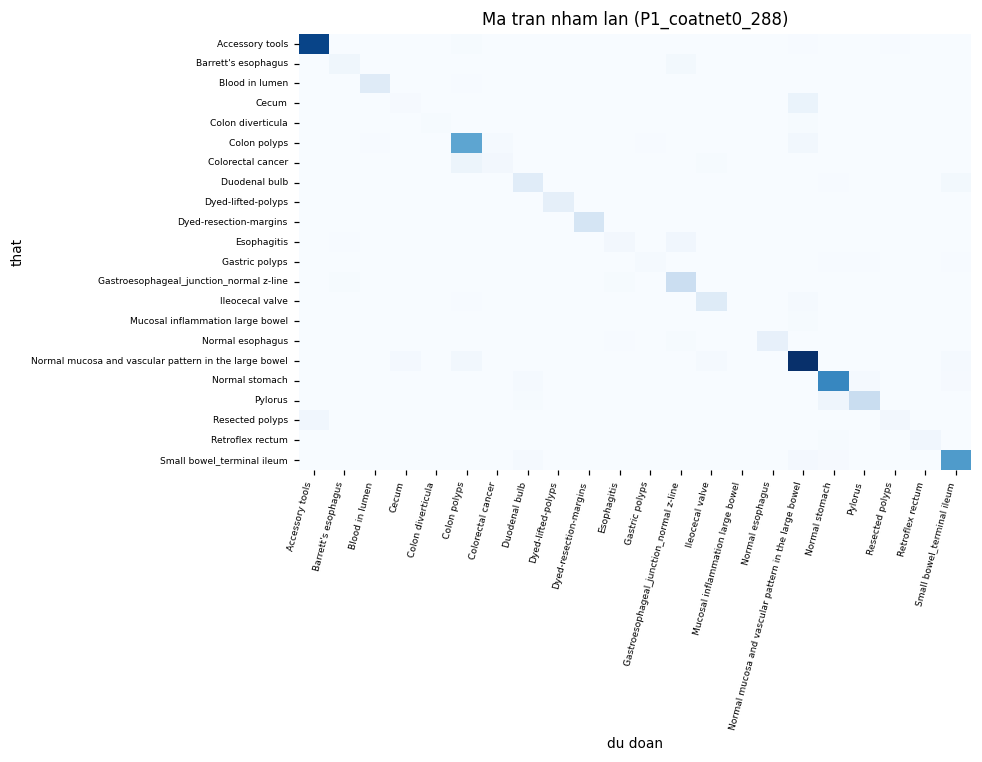


8 lop yeu nhat:
                             lop    F1  so_anh_test  so_anh_train
Mucosal inflammation large bowel 0.000            6            17
                           Cecum 0.242           23            68
               Colorectal cancer 0.372           28            83
                     Esophagitis 0.457           21            64
                  Gastric polyps 0.476           13            39
               Colon diverticula 0.545            6            17
                 Resected polyps 0.552           18            55
             Barrett's esophagus 0.629           19            57

-> Doi chieu cot so_anh_train: neu cac lop yeu deu la lop it anh thi nut that la
   BIEU DIEN DAC TRUNG (thieu du lieu duoi), khong phai ham mat mat.


In [24]:
FOCUS = max(RESULTS_STORE, key=lambda t: RESULTS_STORE[t]["agg"][SELECTION_RULE][0]) \
        if RESULTS_STORE else None

if FOCUS:
    d = load_run(FOCUS, RESULTS_STORE[FOCUS]["seeds"][0])
    res = dict(y_true=d["y_true"], y_pred=sel_scores(d).argmax(1))
    print(f"Mo hinh tot nhat hien tai: {FOCUS}\n")
    report_per_class(res, f"({FOCUS})")
    plot_confusion(res, f"({FOCUS})", fname=f"confusion_{FOCUS}.png")

    f1s = f1_score(res["y_true"], res["y_pred"], labels=ALL_LABELS, average=None, zero_division=0)
    n_test = np.bincount(res["y_true"], minlength=NUM_CLASSES)
    worst = pd.DataFrame({"lop": CLASSES, "F1": np.round(f1s, 3), "so_anh_test": n_test,
                          "so_anh_train": TRAIN_CLASS_COUNTS}).sort_values("F1").head(8)
    print("\n8 lop yeu nhat:")
    print(worst.to_string(index=False))
    print("\n-> Doi chieu cot so_anh_train: neu cac lop yeu deu la lop it anh thi nut that la")
    print("   BIEU DIEN DAC TRUNG (thieu du lieu duoi), khong phai ham mat mat.")

---
## 18. Ba đòn bẩy **không tốn GPU**

Tất cả đều đọc lại từ logits đã lưu. Đây là chỗ để tìm thêm điểm mà không phải xin thêm giờ Colab.

1. **TTA** — đã có sẵn trong bảng ở mục 16.
2. **Hiệu chỉnh logit theo tần suất lớp** — dò τ trên **tập val**, rồi áp một lần lên test.
   Khác với Balanced-Softmax ở chỗ nó tác động lúc **suy luận**, nên không tốn epoch nào.
   ⚠️ **Bảng ngay dưới chỉ là seed 0 — không được đọc nó thành kết luận.** Ở seed 0, τ\* khác 0 rõ
   rệt và `P0` nhảy **+0,0240**, trông như thể một phần lỗi nằm ở ngưỡng quyết định chứ không ở đặc
   trưng. Chạy đủ 3 seed thì điều đó **sụp**: mục 19b cho thấy τ\* mỗi seed một khác (0,9 / 0,5 /
   0,0), toàn bộ cái lợi đến từ **đúng một** seed, và σ phồng ~9×. Notebook **tự động loại** đòn bẩy
   này khỏi hệ thống đề xuất. Giá trị của nó với báo cáo là một **kết quả âm về tính tái lập**,
   không phải một dòng số cải tiến.
3. **Ensemble nhiều kiến trúc** — CNN và Transformer sai ở những chỗ khác nhau, nên trung bình xác suất
   của chúng thường tốt hơn cả hai. Phải báo cáo thành **dòng riêng**: so ensemble với baseline một mô hình
   là so sánh không công bằng.

In [25]:
print(f"=== Don bay 2: hieu chinh logit (tau do tren VAL, quy tac '{SELECTION_RULE}') ===")
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    # val_logits duoc luu cho checkpoint 'best' (thu duy nhat co san). Dung no de do tau roi ap len
    # diem so cua quy tac da chot: tau la hieu chinh prior toan cuc nen chuyen duoc, nhung day van
    # la mot xap xi -- phai noi ro trong bao cao.
    tau, curve = tune_tau(d["val_logits"], d["val_y"])
    lg = as_logits(sel_scores(d))
    base = macro_f1(d["y_true"], lg.argmax(1))
    adj = macro_f1(d["y_true"], logit_adjust(lg, tau=tau).argmax(1))
    print(f"{tag:18s} tau*={tau:.1f}  test: {base:.4f} -> {adj:.4f}  ({adj - base:+.4f})")
print("\n(tau=0 nghia la khong hieu chinh gi; neu tau* ~ 0 thi don bay nay khong co gi de an)")

=== Don bay 2: hieu chinh logit (tau do tren VAL, quy tac 'top3_tta') ===
B0_densenet121     tau*=0.1  test: 0.6768 -> 0.6763  (-0.0006)
S0_swin_t          tau*=0.2  test: 0.6976 -> 0.7029  (+0.0054)
P0_coatnet0        tau*=0.2  test: 0.6805 -> 0.7045  (+0.0240)
P1_coatnet0_288    tau*=0.9  test: 0.6941 -> 0.6952  (+0.0011)

(tau=0 nghia la khong hieu chinh gi; neu tau* ~ 0 thi don bay nay khong co gi de an)


In [26]:
print("=== Don bay 3: ensemble nhieu kien truc (0 epoch) ===")
tags = [t for t in RESULTS_STORE]
if len(tags) >= 2:
    seed0 = RESULTS_STORE[tags[0]]["seeds"][0]
    ds = {t: load_run(t, seed0) for t in tags}
    y = ds[tags[0]]["y_true"]
    assert all(np.array_equal(ds[t]["y_true"], y) for t in tags), \
        "cac mo hinh khong dung chung thu tu tap test -> khong duoc ensemble"

    yv = ds[tags[0]]["val_y"]
    assert all(np.array_equal(ds[t]["val_y"], yv) for t in tags)

    import itertools
    combos = [(t,) for t in tags]
    for k in range(2, len(tags) + 1):
        combos += list(itertools.combinations(tags, k))

    scored = []
    for combo in combos:
        pv = ensemble_logits([ds[t]["val_logits"] for t in combo])
        pt = ensemble_logits([as_logits(sel_scores(ds[t])) for t in combo])
        scored.append((combo, macro_f1(yv, pv.argmax(1)), macro_f1(y, pt.argmax(1))))

    print(f"{'to hop':46s} {'val':>7s} {'test':>7s}")
    for combo, fv, ft in scored:
        print(f"{' + '.join(combo):46s} {fv:7.4f} {ft:7.4f}")

    # Bay chet nguoi: quet 15 to hop roi trich con TEST cao nhat. Do la chon sieu tham so tren
    # chinh tap test -- con so thu duoc khong con la uoc luong khong chech nua.
    by_val = max(scored, key=lambda r: r[1])
    by_test = max(scored, key=lambda r: r[2])
    print(f"\nChon theo VAL     : {' + '.join(by_val[0])}")
    print(f"   -> test = {by_val[2]:.4f}   <== CON SO DUOC PHEP BAO CAO")
    print(f"Cao nhat tren TEST: {' + '.join(by_test[0])} -> {by_test[2]:.4f}"
          f"   (chenh {by_test[2] - by_val[2]:+.4f})")
    print("   Dong tren KHONG duoc bao cao: chon to hop bang chinh tap test la ro ri quy trinh.")
    print("\n-> Ensemble luon la DONG RIENG: no dung nhieu lan huan luyen, khong duoc dat canh")
    print("   mot mo hinh don roi goi la 'cai tien'.")
else:
    print("can it nhat 2 mo hinh da chay xong")

=== Don bay 3: ensemble nhieu kien truc (0 epoch) ===
to hop                                             val    test
B0_densenet121                                  0.6681  0.6768
S0_swin_t                                       0.6791  0.6976
P0_coatnet0                                     0.6630  0.6805
P1_coatnet0_288                                 0.6879  0.6941
B0_densenet121 + S0_swin_t                      0.6922  0.6894
B0_densenet121 + P0_coatnet0                    0.6989  0.6850
B0_densenet121 + P1_coatnet0_288                0.6989  0.6946
S0_swin_t + P0_coatnet0                         0.7077  0.7052
S0_swin_t + P1_coatnet0_288                     0.6992  0.7185
P0_coatnet0 + P1_coatnet0_288                   0.6843  0.6971
B0_densenet121 + S0_swin_t + P0_coatnet0        0.7039  0.6970
B0_densenet121 + S0_swin_t + P1_coatnet0_288    0.6862  0.7155
B0_densenet121 + P0_coatnet0 + P1_coatnet0_288  0.6968  0.7041
S0_swin_t + P0_coatnet0 + P1_coatnet0_288       0.7108  0.7215
B

---
## 19. Bảng tổng kết

Đây là bảng đi thẳng vào báo cáo. Mọi con số đều là **trung bình ± độ lệch chuẩn trên các seed**,
theo **một** quy tắc chọn checkpoint duy nhất.

In [27]:
summary = []
for tag, r in RESULTS_STORE.items():
    m, sd = r["agg"][SELECTION_RULE]
    d = load_run(tag, r["seeds"][0])
    ci = bootstrap_ci(d["y_true"], sel_scores(d).argmax(1), verbose=False)
    summary.append(dict(
        mo_hinh=tag, so_seed=len(r["seeds"]),
        macro_f1=f"{m:.4f} +/- {sd:.4f}",
        ci95_seed0=f"[{ci['lo']:.3f}, {ci['hi']:.3f}]",
        vs_paper=f"{m - PAPER_BASELINE:+.4f}",
        phut_moi_seed=round(np.mean([p.get("train_sec", np.nan) for p in r["per_seed"]]) / 60, 1),
    ))

df = pd.DataFrame(summary)
print(f"Baseline cong bo (DenseNet-121, arXiv 2307.08140): {PAPER_BASELINE}")
print(f"Quy tac chon checkpoint: {SELECTION_RULE} | ho so: {PROFILE}\n")
print(df.to_string(index=False))
df.to_csv(OUTPUT_DIR / "bang_tong_ket.csv", index=False)

if IS_SMOKE:
    print("\n" + "!" * 78)
    print("!! cpu-smoke: bang nay CHI chung minh duong ong chay het. Con so khong dung de bao cao.")
    print("!" * 78)

Baseline cong bo (DenseNet-121, arXiv 2307.08140): 0.6504
Quy tac chon checkpoint: top3_tta | ho so: gpu-a100

        mo_hinh  so_seed          macro_f1     ci95_seed0 vs_paper  phut_moi_seed
 B0_densenet121        3 0.6676 +/- 0.0066 [0.628, 0.713]  +0.0172            9.8
      S0_swin_t        3 0.6851 +/- 0.0114 [0.651, 0.736]  +0.0347            9.6
    P0_coatnet0        3 0.6818 +/- 0.0014 [0.632, 0.719]  +0.0314            9.5
P1_coatnet0_288        3 0.6961 +/- 0.0016 [0.655, 0.725]  +0.0457           10.5


---
## 19b. Hai phép kiểm tra bắt buộc trước khi tuyên bố "vượt baseline"

**(1) Độ bền trước rò rỉ.** Mục 8 tìm ra một số ảnh test có bản gần trùng nằm ở train/val. Nếu bỏ
những ảnh đó đi mà macro-F1 gần như không đổi, thì kết quả **không** được sinh ra bởi rò rỉ — đây là
câu trả lời có số liệu cho câu hỏi người chấm sẽ hỏi, thay vì một lời cam đoan suông.

**(2) Mô hình đề xuất dạng hệ thống.** Bảng ở mục 19 so **thuần kiến trúc**. Còn tuyên bố "vượt 0,6504"
đặt lên **hệ thống đầy đủ**: CoAtNet-0 @288 + TTA + ensemble top-3 checkpoint. Ô dưới ráp các thành
phần lại, chạy trên **cả 3 seed**, và báo trung bình ± độ lệch chuẩn.

**Hiệu chỉnh logit là thành phần thứ tư đang bị thử — không phải thành phần được mặc định giữ.** Ô dưới
đo cả hai biến thể và chỉ giữ nó nếu nó vừa nâng trung bình vừa **không** làm σ phồng quá 50% (tiêu chí
đặt **trước** khi nhìn số). Trên vòng chạy thật nó **bị loại tự động**: mean 0,6961 → 0,7055 nhưng
σ 0,0016 → 0,0139 (~9×), và toàn bộ cái lợi nằm ở đúng một seed trong ba. Đó là một ablation **không
tái lập được**, và bản thân điều đó là một phát hiện đáng viết vào báo cáo.

> Dòng *ensemble 3 seed* được in **riêng**: nó tiêu 3 lần huấn luyện nên không được đặt cạnh
> một mô hình đơn rồi gọi là cải tiến.

In [28]:
# --- (1) Bo cac anh test bi nghi ro ri roi tinh lai: ket qua co ben khong? ---
if "LEAK_TEST_IDS" in dir() and RESULTS_STORE:
    pos = {int(g): k for k, g in enumerate(test_idx)}      # id anh toan cuc -> vi tri trong logits
    bad = sorted({pos[i] for i in LEAK_TEST_IDS if i in pos})
    keep = np.setdiff1d(np.arange(len(test_idx)), bad)
    print(f"Bo {len(bad)} / {len(test_idx)} anh test bi nghi ro ri (trung byte hoac cosine >= {AUDIT_TH})\n")
    print(f"{'mo hinh':18s} {'day du':>8s} {'da loc':>8s} {'chenh':>8s}")
    for tag, r in RESULTS_STORE.items():
        d = load_run(tag, r["seeds"][0])
        p = sel_scores(d).argmax(1)
        f_all = macro_f1(d["y_true"], p)
        f_cln = f1_score(d["y_true"][keep], p[keep], labels=ALL_LABELS,
                         average="macro", zero_division=0)
        print(f"{tag:18s} {f_all:8.4f} {f_cln:8.4f} {f_cln - f_all:+8.4f}")
    print("\n-> Chenh lech nho hon do lech chuan giua cac seed nghia la ro ri KHONG phai nguon")
    print("   sinh ra ket qua. Chenh lech lon thi phai bao cao con so DA LOC lam so chinh.")
else:
    print("chua chay o audit ro ri o muc 8")

Bo 6 / 1586 anh test bi nghi ro ri (trung byte hoac cosine >= 0.98)

mo hinh              day du   da loc    chenh
B0_densenet121       0.6768   0.6749  -0.0020
S0_swin_t            0.6976   0.6953  -0.0022
P0_coatnet0          0.6805   0.6787  -0.0018
P1_coatnet0_288      0.6941   0.6922  -0.0019

-> Chenh lech nho hon do lech chuan giua cac seed nghia la ro ri KHONG phai nguon
   sinh ra ket qua. Chenh lech lon thi phai bao cao con so DA LOC lam so chinh.


In [29]:
# --- (2) HE THONG DE XUAT DAY DU tren ca 3 seed ---
PROPOSED_TAG = "P1_coatnet0_288"

if PROPOSED_TAG in RESULTS_STORE:
    r = RESULTS_STORE[PROPOSED_TAG]
    f_raws, f_adjs, taus, probs_raw, probs_adj, yt = [], [], [], [], [], None
    print(f"{PROPOSED_TAG} + TTA + ensemble top-3 checkpoint  (+/- hieu chinh logit)\n")
    for sd_i in r["seeds"]:
        d = load_run(PROPOSED_TAG, sd_i)
        lg = as_logits(sel_scores(d, "top3_tta"))     # ensemble top-K checkpoint DA co TTA
        tau, _ = tune_tau(d["val_logits"], d["val_y"])
        adj = logit_adjust(lg, tau=tau)
        f_raw, f_adj = macro_f1(d["y_true"], lg.argmax(1)), macro_f1(d["y_true"], adj.argmax(1))
        f_raws.append(f_raw); f_adjs.append(f_adj); taus.append(tau)
        probs_raw.append(softmax_np(lg)); probs_adj.append(softmax_np(adj))
        yt = d["y_true"]
        print(f"  seed {sd_i}: top3+TTA = {f_raw:.4f}   tau*={tau:.1f} -> {f_adj:.4f}"
              f"  ({f_adj - f_raw:+.4f})")

    # Hieu chinh logit la thanh phan DUY NHAT trong he thong co sieu tham so do lai theo tung seed,
    # nen no phai tu chung minh gia tri chu khong duoc mac dinh bat. Doi chieu song song:
    m_raw, s_raw = float(np.mean(f_raws)), float(np.std(f_raws))
    m_adj, s_adj = float(np.mean(f_adjs)), float(np.std(f_adjs))
    print(f"\n{'bien the':>18s} {'trung binh':>11s} {'do lech':>9s}")
    print(f"{'khong hieu chinh':>18s} {m_raw:11.4f} {s_raw:9.4f}")
    print(f"{'co hieu chinh':>18s} {m_adj:11.4f} {s_adj:9.4f}")

    # Tieu chi dat TRUOC khi nhin so: chi giu hieu chinh logit neu no vua tang trung binh vua
    # KHONG lam phinh do lech giua cac seed. Mot con so cao hon nhung kem tai lap hon thi khong
    # dung de bao cao -- do dung la can benh ma muc 6 dang co gang chua.
    use_adj = (m_adj > m_raw) and (s_adj <= s_raw * 1.5)
    if use_adj:
        chosen, m, sd_, probs_seeds = "co hieu chinh logit", m_adj, s_adj, probs_adj
    else:
        chosen, m, sd_, probs_seeds = "khong hieu chinh logit", m_raw, s_raw, probs_raw
        if m_adj > m_raw:
            tau_s = ", ".join(f"{t:.1f}" for t in taus)
            print(f"\n   !! Hieu chinh logit cao hon {m_adj - m_raw:+.4f} nhung do lech phinh tu "
                  f"{s_raw:.4f} len {s_adj:.4f}.")
            print(f"      tau* moi seed mot khac ({tau_s}) -> muc tang la cua MOT seed,")
            print("      khong phai cua phuong phap. Bo khoi he thong, bao cao rieng thanh mot")
            print("      ablation KHONG tai lap duoc giua cac seed.")
    ci1 = bootstrap_ci(yt, probs_seeds[0].argmax(1), verbose=False)

    print(f"\nHE THONG DE XUAT ({chosen})")
    print(f"                   macro-F1 = {m:.4f} +/- {sd_:.4f}  tren {len(f_raws)} seed")
    print(f"                   so voi paper {PAPER_BASELINE}: {m - PAPER_BASELINE:+.4f}")
    print(f"                   CI 95% (seed dau) = [{ci1['lo']:.4f}, {ci1['hi']:.4f}]")

    ens = ensemble_logits([as_logits(p) for p in probs_seeds])
    ci3 = bootstrap_ci(yt, ens.argmax(1), verbose=False)
    print(f"\n+ ensemble ca 3 seed  macro-F1 = {ci3['point']:.4f}  "
          f"CI 95% [{ci3['lo']:.4f}, {ci3['hi']:.4f}]   (DONG RIENG: ton 3 lan huan luyen)")
    if ci3["lo"] > PAPER_BASELINE:
        print("  -> CI khong chong lan 0,6504: duoc quyen noi 'vuot baseline cong bo'.")
    else:
        print("  -> CI van chong lan 0,6504: chi duoc noi 'cao hon nhung chua tach bach thong ke'.")
else:
    print(f"chua co {PROPOSED_TAG} (dat RUN_P1_288 = True o muc 15b)")

P1_coatnet0_288 + TTA + ensemble top-3 checkpoint  (+/- hieu chinh logit)

  seed 0: top3+TTA = 0.6941   tau*=0.9 -> 0.6952  (+0.0011)
  seed 1: top3+TTA = 0.6980   tau*=0.5 -> 0.7252  (+0.0271)
  seed 2: top3+TTA = 0.6961   tau*=0.0 -> 0.6961  (+0.0000)

          bien the  trung binh   do lech
  khong hieu chinh      0.6961    0.0016
     co hieu chinh      0.7055    0.0139

   !! Hieu chinh logit cao hon +0.0094 nhung do lech phinh tu 0.0016 len 0.0139.
      tau* moi seed mot khac (0.9, 0.5, 0.0) -> muc tang la cua MOT seed,
      khong phai cua phuong phap. Bo khoi he thong, bao cao rieng thanh mot
      ablation KHONG tai lap duoc giua cac seed.

HE THONG DE XUAT (khong hieu chinh logit)
                   macro-F1 = 0.6961 +/- 0.0016  tren 3 seed
                   so voi paper 0.6504: +0.0457
                   CI 95% (seed dau) = [0.6548, 0.7245]

+ ensemble ca 3 seed  macro-F1 = 0.7221  CI 95% [0.6728, 0.7609]   (DONG RIENG: ton 3 lan huan luyen)
  -> CI khong chong lan 0,650

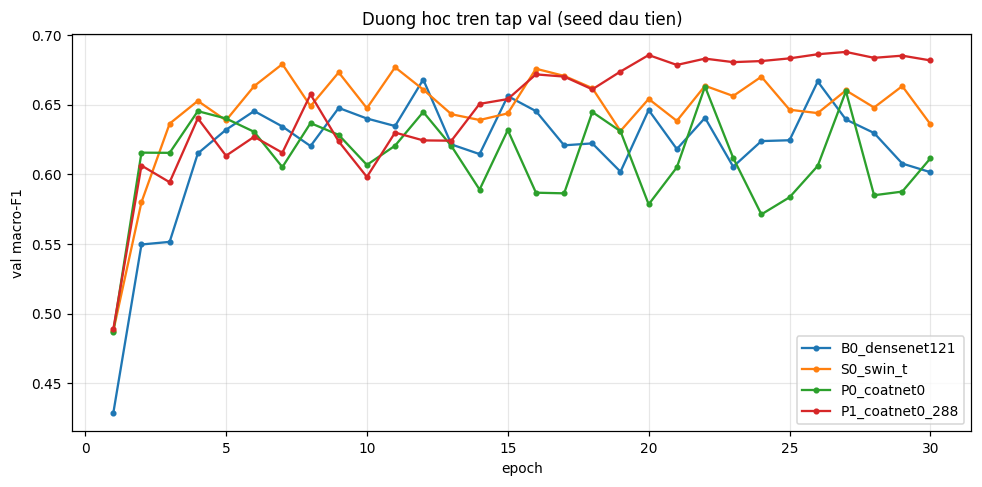

B0_densenet121     val cao nhat=0.6681 tai epoch 12 | do lech 5 epoch cuoi=0.0234
S0_swin_t          val cao nhat=0.6791 tai epoch  7 | do lech 5 epoch cuoi=0.0102
P0_coatnet0        val cao nhat=0.6630 tai epoch 22 | do lech 5 epoch cuoi=0.0269
P1_coatnet0_288    val cao nhat=0.6879 tai epoch 27 | do lech 5 epoch cuoi=0.0021


In [30]:
# --- Duong hoc val: chan doan overfit va do nhieu cua tung kien truc ---
plt.figure(figsize=(9, 4.5))
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    plt.plot(range(1, len(d["history"]) + 1), d["history"], marker="o", ms=3, label=tag)
plt.xlabel("epoch"); plt.ylabel("val macro-F1")
plt.title("Duong hoc tren tap val (seed dau tien)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "val_curves.png", dpi=130); plt.show()

for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    h = d["history"]
    if len(h) > 3:
        print(f"{tag:18s} val cao nhat={h.max():.4f} tai epoch {int(h.argmax()) + 1:2d} | "
              f"do lech 5 epoch cuoi={h[-5:].std():.4f}")

---
## 19c. Ablation (tuỳ chọn — mặc định tắt)

Hai dòng dưới đây lấp hai lời hứa còn lại nằm rải trong notebook: trọng số **in22k** của Swin-T
(mục 12) và **Balanced-Softmax** (mục 11). Mỗi dòng chạy **1 seed** để rẻ — đủ để làm phần *kết quả
âm* của báo cáo, không đủ để tuyên bố hơn/kém.

*(Lời hứa thứ ba — công thức fine-tune 2 giai đoạn `train_advanced` — **không** nằm ở đây: nó chính
là điều kiện `T3` của mục 19d và đã chạy thật. Mục này từng có thêm một dòng `A3_2stage_ft` lặp lại
y hệt T3; đã bỏ.)*

Đặt `RUN_ABLATIONS = True` nếu phiên A100 còn dư ~20 phút. Ô này nằm **sau** mọi bảng chính nên
kết quả ablation không lẫn vào bảng so sánh 3 kiến trúc. ⚠️ Trong bản notebook đang đọc,
`RUN_ABLATIONS = False` nên **chưa dòng nào trong hai dòng này từng chạy**.

In [31]:
RUN_ABLATIONS = False     # True = them ~20 phut A100 (moi dong 1 seed)
ABL_SEEDS = [0]

if RUN_ABLATIONS and timm is not None:
    set_img_size(224); use_aug(False)

    # A1: Swin-T voi trong so in22k -- KHONG duoc dua vao dong baseline (pha the can bang in1k
    #     voi DenseNet-121), chi duoc dung lam ablation "trong so pretrain manh hon giup bao nhieu".
    run_seeds(build_swin_t_in22k, tag="A1_swin_in22k", seeds=ABL_SEEDS)

    # A2: Balanced-Softmax tren DenseNet-121 -- vong truoc do duoc -0,007 (phang).
    run_seeds(build_densenet121, tag="A2_balanced_softmax", seeds=ABL_SEEDS,
              criterion=BalancedSoftmaxLoss(TRAIN_CLASS_COUNTS).to(DEVICE))

    # (Cong thuc 2 giai doan KHONG con o day: no chinh la T3_progressive_lr o muc 19d va da chay
    #  that. Truoc kia cho nay co dong A3_2stage_ft lap lai y het T3 -> da bo.)

    print("\nSo voi dong goc cung 1 seed:")
    for a, b in (("A1_swin_in22k", "S0_swin_t"), ("A2_balanced_softmax", "B0_densenet121")):
        if a in RESULTS_STORE and b in RESULTS_STORE:
            fa = RESULTS_STORE[a]["per_seed"][0][SELECTION_RULE]
            fb = RESULTS_STORE[b]["per_seed"][0][SELECTION_RULE]
            print(f"  {a:22s} {fa:.4f}  vs  {b:18s} {fb:.4f}   ({fa - fb:+.4f})")
else:
    print("bo qua ablation (dat RUN_ABLATIONS = True neu con gio GPU)")

bo qua ablation (dat RUN_ABLATIONS = True neu con gio GPU)


---
## 19d. Transfer learning — **freeze vs trainable** (10% của rubric)

Đây **không** phải phần tuỳ chọn. Rubric của đề bài (`../../mse-dl-de-bai-vuot-baseline.pdf`, mục 6
*"Khung report bám đúng tỉ lệ 70/30"*) cho hạng mục này **10%** và ghi rõ nội dung cần có:
*"Linear probe / progressive unfreezing / layer-wise LR decay / full fine-tune. **Bảng so sánh**."*

Bốn điều kiện dưới đây trên **cùng một backbone (DenseNet-121)**, cùng split, cùng seed, cùng số
epoch — chỉ **độ sâu được phép học** là khác. Full fine-tune **không phải chạy lại**: đó chính là
`B0` ở mục 15.

| Điều kiện | Học cái gì | Hàm |
| --- | --- | --- |
| **T1 · linear probe** | chỉ lớp phân loại; backbone đóng băng hoàn toàn (kể cả BatchNorm) | `train_linear_probe` |
| **T2 · đóng băng một nửa** | nửa trên backbone + lớp phân loại | `train_partial_unfreeze(frac=0.5)` |
| **T3 · progressive unfreeze + LR phân biệt** | probe 3 epoch → mở toàn mạng, LR backbone 0,5× LR head, cosine warmup | `train_advanced` |
| **T4 · full fine-tune** | toàn mạng, một LR duy nhất | `train_one` = **`B0`, đã có 3 seed** |

**Hai điều phải nói thẳng trong báo cáo:**

1. **T3 là "LR phân biệt 2 nhóm", không phải "layer-wise LR decay" đúng nghĩa.** Rubric nêu bốn kỹ
   thuật; chúng tôi làm ba, và nhóm LR chỉ chia thành backbone / head thay vì hệ số suy giảm riêng
   cho từng block. Lý do là giá: mỗi điều kiện thêm là ~10 phút GPU, và đòn bẩy này đã được đo là
   nhỏ hơn nhiễu đo trên tập ~8k ảnh.
2. **Mỗi điều kiện chỉ 1 seed** (T4 có 3 seed vì nó là `B0`). Nên bảng này **xếp hạng thô**, không
   được dùng để tuyên bố hơn kém vài phần nghìn — đúng nguyên tắc số 4 ở mục 21. Điều nó **được**
   phép nói là những khác biệt **lớn hơn hẳn** σ đã đo (0,0014–0,0114 dưới `top3_tta` tuỳ mô hình;
   ô dưới lấy σ của chính `B0` = 0,0066 làm thước đo, vì T4 là dòng đối chứng).

**Có một bảng so sánh nữa đến miễn phí, và nó mạnh hơn bảng của chúng ta:** Table 2 của chính bài
báo là một thí nghiệm độ sâu đóng băng núp bóng so sánh kiến trúc. Theo §4.2 của họ, DenseNet-121 và
ResNet-50 (dòng thứ hai) fine-tune **toàn mạng** → 0,6504 / 0,6176; còn ResNet-152, EfficientNet-B0,
DenseNet-169 chỉ fine-tune **lớp cuối** → 0,4496 / 0,4519 / 0,4883. Chênh **~0,16 macro-F1 trên đúng
split này**, tức đúng thứ T1-vs-T4 đang đo, với n lớn hơn. Trích nó làm đối chứng, và cũng để nói
rằng phần lớn độ tán trong Table 2 là **độ sâu fine-tune, không phải kiến trúc** (`RESULTS.md` §0b).

> Đánh số **19d** thay vì 20 để khớp thứ tự chạy — mục này dùng `run_seeds` như mục 15 — và để
> `README.md` / `RESULTS.md` vẫn trích đúng số hiệu của mục 20 và 21.

In [32]:
RUN_TRANSFER = True      # 10% cua rubric -- chi tat khi that su het gio GPU
TL_SEEDS = [0]           # 1 seed moi dieu kien; T4 = B0 da co 3 seed

if RUN_TRANSFER:
    set_img_size(224); use_aug(False)

    # T1: linear probe -- backbone dong bang hoan toan (BatchNorm ve eval), chi hoc lop cuoi.
    run_seeds(build_densenet121, tag="T1_linear_probe", seeds=TL_SEEDS,
              train_fn=train_linear_probe)

    # T2: dong bang nua duoi backbone.
    run_seeds(build_densenet121, tag="T2_partial_unfreeze", seeds=TL_SEEDS,
              train_fn=train_partial_unfreeze)

    # T3: probe -> mo toan mang, LR phan biet + cosine warmup.
    run_seeds(build_densenet121, tag="T3_progressive_lr", seeds=TL_SEEDS,
              train_fn=train_advanced)
else:
    print("bo qua muc transfer learning (RUN_TRANSFER = False) -- day la 10% cua rubric")

IMG_SIZE -> 224 (dung augment 'plain')
augment -> plain
[T1_linear_probe seed 0] doc lai tu T1_linear_probe_seed0.npz (bo qua huan luyen)
   best=0.5802  best_tta=0.5726  smooth=0.5802  smooth_tta=0.5726  top3=0.5561  top3_tta=0.5725

>>> T1_linear_probe  TEST macro-F1 (quy tac 'top3_tta') = 0.5725 +/- 0.0000   tren 1 seed
[T2_partial_unfreeze seed 0] doc lai tu T2_partial_unfreeze_seed0.npz (bo qua huan luyen)
   best=0.6329  best_tta=0.6425  smooth=0.6182  smooth_tta=0.6319  top3=0.6431  top3_tta=0.6463

>>> T2_partial_unfreeze  TEST macro-F1 (quy tac 'top3_tta') = 0.6463 +/- 0.0000   tren 1 seed
[T3_progressive_lr seed 0] doc lai tu T3_progressive_lr_seed0.npz (bo qua huan luyen)
   best=0.6400  best_tta=0.6513  smooth=0.6400  smooth_tta=0.6513  top3=0.6338  top3_tta=0.6472

>>> T3_progressive_lr  TEST macro-F1 (quy tac 'top3_tta') = 0.6472 +/- 0.0000   tren 1 seed


In [33]:
# --- Bang so sanh: 4 dieu kien, cung backbone / split / seed / so epoch ---
TL_ROWS = [("T1_linear_probe",     "T1 linear probe",              "chi lop phan loai"),
           ("T2_partial_unfreeze", "T2 dong bang nua duoi",        "nua tren + lop phan loai"),
           ("T3_progressive_lr",   "T3 progressive + LR phan biet","probe 3 ep -> toan mang, LR bb 0,5x"),
           ("B0_densenet121",      "T4 full fine-tune (= B0)",     "toan mang, mot LR")]

rows = []
for tag, ten, mo_ta in TL_ROWS:
    if tag not in RESULTS_STORE:
        continue
    st = RESULTS_STORE[tag]
    seed0 = st["per_seed"][0]
    m, sd = st["agg"][SELECTION_RULE]
    rows.append({"dieu_kien": ten, "hoc_gi": mo_ta, "so_seed": len(st["seeds"]),
                 f"test_{SELECTION_RULE}": round(m, 4), "do_lech": round(sd, 4),
                 "best_val": round(seed0["best_val"], 4),
                 "phut": round(seed0.get("train_sec", float("nan")) / 60, 1)})

if rows:
    tl = pd.DataFrame(rows)
    print(f"Transfer learning -- cung DenseNet-121, cung split/seed/epoch, quy tac '{SELECTION_RULE}'\n")
    print(tl.to_string(index=False))

    ft = next((r for r in rows if r["dieu_kien"].startswith("T4")), None)
    if ft is not None:
        base = ft[f"test_{SELECTION_RULE}"]
        # Nguong: 2 x sigma da do cua B0 duoi top3_tta. Voi 1 seed thi khong the tinh sigma rieng
        # cho tung dieu kien, nen lay sigma cua chinh baseline lam thuoc do -- va noi ro nhu vay.
        sigma = max(ft["do_lech"], 0.0065)
        print(f"\nSo voi full fine-tune ({base:.4f}); nguong 'dang ke' = 2 sigma = {2 * sigma:.4f}")
        print("(sigma lay tu 3 seed cua B0, khong phai cua tung dieu kien -- moi dieu kien chi 1 seed)")
        for r in rows:
            if r is ft:
                continue
            d = r[f"test_{SELECTION_RULE}"] - base
            note = "DANG KE" if abs(d) > 2 * sigma else "trong nhieu do (1 seed) -> khong ket luan"
            print(f"  {r['dieu_kien']:32s} {d:+.4f}   {note}")

    print("\nDoi chung tu Table 2 cua bai bao (cung split, n lon hon):")
    print("  chi fine-tune lop cuoi : ResNet-152 0.4496 | EfficientNet-B0 0.4519 | DenseNet-169 0.4883")
    print("  fine-tune toan mang    : ResNet-50  0.6176 | DenseNet-121    0.6504")
    print("  -> chenh ~0,16 macro-F1, cung chieu voi T1 vs T4 o tren.")
    tl.to_csv(OUTPUT_DIR / "bang_transfer_learning.csv", index=False)
    print(f"\nda luu {OUTPUT_DIR / 'bang_transfer_learning.csv'}")
else:
    print("chua co so cho muc transfer learning (dat RUN_TRANSFER = True roi chay lai)")

Transfer learning -- cung DenseNet-121, cung split/seed/epoch, quy tac 'top3_tta'

                    dieu_kien                              hoc_gi  so_seed  test_top3_tta  do_lech  best_val  phut
              T1 linear probe                   chi lop phan loai        1         0.5725   0.0000    0.5376   9.2
        T2 dong bang nua duoi            nua tren + lop phan loai        1         0.6463   0.0000    0.6246   9.3
T3 progressive + LR phan biet probe 3 ep -> toan mang, LR bb 0,5x        1         0.6472   0.0000    0.6249  10.9
     T4 full fine-tune (= B0)                   toan mang, mot LR        3         0.6676   0.0066    0.6681   9.7

So voi full fine-tune (0.6676); nguong 'dang ke' = 2 sigma = 0.0132
(sigma lay tu 3 seed cua B0, khong phai cua tung dieu kien -- moi dieu kien chi 1 seed)
  T1 linear probe                  -0.0951   DANG KE
  T2 dong bang nua duoi            -0.0213   DANG KE
  T3 progressive + LR phan biet    -0.0204   DANG KE

Doi chung tu Table 2 cua 

---
## 20. Triển khai — ONNX, độ trễ, kích thước

Phần này phục vụ tiêu chí *"tính hoàn chỉnh của sản phẩm"*: một mô hình y tế còn phải trả lời được
**chạy nhanh chậm ra sao và nặng bao nhiêu**, chứ không chỉ macro-F1.

In [34]:
# Tra ve ms cho MOI ANH. Canh bao khi doc bang: o batch = 1 tren A100, GPU rong gan het thoi gian
# -- con so do duoc bi chi phoi boi SO LAN KHOI CHAY KERNEL chu khong phai so phep tinh. Vi vay
# DenseNet-121 (7 M tham so nhung ~120 lop) do ra "cham" hon CoAtNet-0 (26,7 M), va 288x288 do ra
# NGANG 224x224 du gap 1,65 lan diem anh. Muon so chi phi tinh toan thi phai doc cot batch lon.
@torch.no_grad()
def measure_latency(model, iters=None, warmup=5, batch=1):
    iters = iters or CFG["latency_iters"]
    model.eval()
    x = torch.randn(batch, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for _ in range(warmup):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / iters / batch * 1000     # ms/anh


def export_onnx(m, path, size):
    '''Tra ve (kich thuoc MB, trang thai).

    torch >= 2.9 mac dinh dung bo xuat dua tren torch.export (can onnxscript); ban cu can onnx.
    external_data=False ep trong so nam trong CHINH file .onnx: mac dinh cua bo xuat moi la tach ra
    file .onnx.data, khien file .onnx chi con ~1 MB va so lieu "kich thuoc mo hinh" thanh sai.
    Thu lan luot 3 duong -> khong phu thuoc phien ban torch cua Colab.'''
    dummy = torch.randn(1, 3, size, size, device=DEVICE)
    err = "chua thu"
    for kw in ({"external_data": False}, {}, {"dynamo": False}):
        try:
            torch.onnx.export(m, dummy, str(path), input_names=["input"],
                              output_names=["logits"], opset_version=18, verbose=False,
                              dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, **kw)
            # Cong ca file trong so tach roi (neu co) de con so la kich thuoc THAT khi trien khai.
            mb = sum(f.stat().st_size for f in path.parent.glob(path.name + "*")) / 1e6
            return mb, "OK"
        except Exception as e:
            err = "LOI: " + type(e).__name__
    return float("nan"), err + " (thieu goi onnx/onnxscript -> chay lai o pip dau notebook)"


# Mo hinh DE XUAT chay o 288 chu khong phai 224. Neu bang trien khai chi co dong 224 thi no dang
# mo ta mot cau hinh KHONG AI DUNG -> them dong rieng cho dung cau hinh se giao.
BENCH_BATCH = 32
BENCH = [(name, fn, 224) for name, fn in BUILDERS.items()]
if "coatnet0" in BUILDERS:
    BENCH.append(("coatnet0 @288", BUILDERS["coatnet0"], 288))

rows = []
_keep_size = IMG_SIZE
for name, fn, size in BENCH:
    set_img_size(size)
    m = fn(NUM_CLASSES)
    ms = measure_latency(m)
    # Cot thu hai o batch lon: tach do tre KHOI CHAY KERNEL ra khoi chi phi TINH TOAN that su.
    ms_b = measure_latency(m, batch=BENCH_BATCH) if DEVICE == "cuda" else float("nan")
    mb, ok = export_onnx(m, OUTPUT_DIR / f"{name.replace(' @', '_')}.onnx", size)
    rows.append(dict(mo_hinh=name, do_phan_giai=size,
                     trieu_tham_so=round(PARAM_COUNTS.get(name.split()[0], float("nan")), 1),
                     ms_batch1=round(ms, 1), ms_batch=round(ms_b, 2),
                     onnx_MB=round(mb, 1), xuat_onnx=ok))
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
set_img_size(_keep_size)

print(f"\nDo tren {GPU_NAME}\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nms_batch1 = do tre mot anh mot (kich ban lam sang) -- bi chi phoi boi so lan khoi chay kernel.")
print(f"ms_batch  = ms/anh khi chay batch {BENCH_BATCH} (kich ban xu ly lo) -- phan anh chi phi TINH TOAN.")
print("Hai cot co the xep hang KHAC NHAU; do la thong tin ve kien truc, khong phai loi do.")

IMG_SIZE -> 224 (dung augment 'plain')
IMG_SIZE -> 224 (dung augment 'plain')
IMG_SIZE -> 224 (dung augment 'plain')


IMG_SIZE -> 288 (dung augment 'plain')


IMG_SIZE -> 224 (dung augment 'plain')

Do tren NVIDIA A100-SXM4-40GB

      mo_hinh  do_phan_giai  trieu_tham_so  ms_batch1  ms_batch  onnx_MB xuat_onnx
  densenet121           224            7.0       18.9      0.58     29.1        OK
       swin_t           224           27.5       23.5      0.73    113.7        OK
     coatnet0           224           26.7       13.4      0.59    110.4        OK
coatnet0 @288           288           26.7       13.2      0.99    114.8        OK

ms_batch1 = do tre mot anh mot (kich ban lam sang) -- bi chi phoi boi so lan khoi chay kernel.
ms_batch  = ms/anh khi chay batch 32 (kich ban xu ly lo) -- phan anh chi phi TINH TOAN.
Hai cot co the xep hang KHAC NHAU; do la thong tin ve kien truc, khong phai loi do.


In [35]:
# --- Uoc luong ngan sach Colab tu so do that ---
if IS_SMOKE and RESULTS_STORE:
    n_smoke = len(train_idx)
    n_full = len(FULL_SPLIT["train"])
    scale_data = n_full / n_smoke
    print(f"Do tren CPU voi {n_smoke} anh train; chay that co {n_full} anh -> gap {scale_data:.0f} lan")
    print(f"{'mo hinh':18s} {'giay/epoch (CPU)':>17s} {'suy ra 30 epoch, T4':>22s} {'A100':>10s}")
    for tag, r in RESULTS_STORE.items():
        spe = np.mean([p.get("sec_per_epoch", np.nan) for p in r["per_seed"]])
        full_cpu_h = spe * scale_data * 30 / 3600
        print(f"{tag:18s} {spe:17.1f} {full_cpu_h / 25:19.1f} h {full_cpu_h / 70:9.1f} h")
    print("\nHe so quy doi CPU->GPU o day la uoc luong tho (T4 ~25x, A100 ~70x so voi 16 luong CPU).")
    print("Dung de LAP KE HOACH phien Colab, khong phai de bao cao.")

---
## 20b. Demo Gradio — *"Completeness of the Product"*

Đề bài nói thẳng ở p2: *"một notebook chạy được là chưa đủ — cần sản phẩm hoàn chỉnh có demo"*, và
hạng mục 7 của rubric ghi *"export ONNX, đo latency + kích thước model, demo Gradio/Streamlit"*.
Mục 20 đã làm ba việc đầu; ô dưới làm việc còn lại.

**Một hạn chế phải nói rõ, không được để người đọc tự suy ra.** `run_seeds` chỉ lưu **một**
checkpoint (`{tag}_seed{seed}.pt`, cái tốt nhất theo val), trong khi hệ thống đề xuất là **ensemble
3 checkpoint × 2 chiều lật** = 6 lượt suy luận. Nên demo chạy **1 checkpoint + TTA lật ngang**, tức
tương đương quy tắc `best_tta` (~0,673 với P1), **không phải** `top3_tta` (0,6961). Muốn demo đúng
hệ thống thì phải lưu cả 3 trạng thái trong `run_seeds` rồi huấn luyện lại — khoảng 1,3 GB checkpoint
trên Drive cho cả 4 cấu hình, và **không** khôi phục được từ các lần chạy cũ vì chúng chỉ lưu 1 state.
Đây là một khoảng cách có thật giữa "số trong báo cáo" và "thứ chạy trong demo"; ghi nó vào báo cáo
thì mạnh hơn là im lặng.

Demo in **top-5 lớp kèm xác suất** thay vì một nhãn duy nhất: với 22 lớp mất cân bằng và những lớp
hiếm mà mô hình còn sai (mục 17), một nhãn đơn là thứ dễ gây hiểu sai nhất trong bối cảnh y tế.

In [36]:
RUN_DEMO = True          # 0 GPU huan luyen; chi tai lai checkpoint da co
DEMO_SHARE = False       # True = Gradio tao link cong khai (72 gio) de nop kem bao cao
# globals().get: o nay chay duoc DOC LAP, khong bat buoc phai chay muc 19b truoc.
DEMO_TAG = globals().get("PROPOSED_TAG", "P1_coatnet0_288")
DEMO_SEED = SEEDS[0]

# Dung lai DUNG builder + do phan giai cua cau hinh de xuat, roi nap checkpoint da luu.
def _load_demo_model():
    spec = {"B0_densenet121": (build_densenet121, 224), "S0_swin_t": (build_swin_t, 224),
            "P0_coatnet0": (build_coatnet0, 224), "P1_coatnet0_288": (build_coatnet0, 288)}
    if DEMO_TAG not in spec:
        raise KeyError(f"chua khai bao builder cho {DEMO_TAG}")
    build_fn, size = spec[DEMO_TAG]
    ckpt = CKPT_DIR / f"{DEMO_TAG}_seed{DEMO_SEED}.pt"
    if not ckpt.exists():
        raise FileNotFoundError(f"khong thay {ckpt} -- chay muc 15/15b truoc, hoac doi DEMO_TAG")
    # PHAI dat IMG_SIZE truoc khi build: _timm_build doc bien toan cuc nay, va bang
    # relative-position bias cua CoAtNet/Swin co kich thuoc PHU THUOC do phan giai. Build o 224
    # roi nap checkpoint 288 se bao "size mismatch ... relative_position_bias_table".
    _keep = IMG_SIZE
    try:
        set_img_size(size)
        model = build_fn(NUM_CLASSES)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    finally:
        set_img_size(_keep)
    model.to(DEVICE).eval()
    _, _, tf = build_transforms(size)
    return model, tf, size


# Duong suy luan duoc tach KHOI Gradio: no phai kiem tra duoc ma khong can UI, va khi khong co
# gradio thi phan con lai cua notebook van chay tiep.
demo_model = None
if RUN_DEMO:
    try:
        demo_model, demo_tf, demo_size = _load_demo_model()
        print(f"demo: da nap {DEMO_TAG} seed {DEMO_SEED} @ {demo_size}px tren {DEVICE}")
    except (FileNotFoundError, KeyError, RuntimeError) as e:
        # RuntimeError = state_dict khong khop (sai kien truc hoac sai do phan giai).
        print("bo qua demo:", str(e)[:300])
else:
    print("bo qua demo (RUN_DEMO = False)")

if demo_model is not None:
    @torch.no_grad()
    def du_doan(img):
        '''Tra ve {ten lop: xac suat} cho top-5. TTA lat ngang -- DUNG phep bien doi ma muc 16 da do.'''
        if img is None:
            return {}
        x = demo_tf(img.convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            p = (demo_model(x).softmax(1)
                 + demo_model(torch.flip(x, dims=[3])).softmax(1)) / 2
        p = p.float().cpu().numpy()[0]
        return {CLASSES[i]: float(p[i]) for i in p.argsort()[::-1][:5]}

    # Tu kiem tra tren mot anh test that: chung minh duong suy luan chay TRUOC khi dung UI.
    _p, _y = samples[test_idx[0]]
    _top = du_doan(Image.open(_p))
    _ten, _xs = next(iter(_top.items()))
    print(f"  tu kiem tra: that = {CLASSES[_y]!r} | du doan = {_ten!r} ({_xs:.3f})")

    try:
        import gradio as gr
    except ImportError:
        gr = None
        print("  chua co gradio -> pip install gradio (da co trong requirements.txt); "
              "duong suy luan van dung, chi thieu UI")

    if gr is not None:
        mo_ta = (f"**{DEMO_TAG}** (seed {DEMO_SEED}), {demo_size}x{demo_size}, TTA lat ngang. "
                 f"22 lop GastroVision.\n\n"
                 f"LUU Y: day la MOT checkpoint + TTA (~quy tac 'best_tta'), KHONG phai he thong "
                 f"'top3_tta' = 0,6961 trong bao cao -- xem chu thich o o tren.\n\n"
                 f"Cong cu ho tro sang loc, KHONG phai thiet bi chan doan.")
        demo = gr.Interface(fn=du_doan,
                            inputs=gr.Image(type="pil", label="Anh noi soi"),
                            outputs=gr.Label(num_top_classes=5, label="Top-5 du doan"),
                            title="GastroVision - phan loai anh noi soi tieu hoa",
                            description=mo_ta)
        # prevent_thread_lock: khong co no thi o nay CHAN, va muc 21 khong bao gio chay.
        demo.launch(share=DEMO_SHARE, quiet=True, inline=True, prevent_thread_lock=True)

IMG_SIZE -> 288 (dung augment 'plain')
IMG_SIZE -> 224 (dung augment 'plain')
demo: da nap P1_coatnet0_288 seed 0 @ 288px tren cuda
  tu kiem tra: that = 'Accessory tools' | du doan = 'Accessory tools' (1.000)


<IPython.core.display.Javascript object>

---
## 21. Kế hoạch chạy, phân công và các quyết định đã chốt

> **Trạng thái:** cả 5 phiên dưới đây **đã chạy xong** trên A100 — bản notebook này là lần chạy thứ
> tư, nạp lại kết quả từ Drive (xem ghi chú ở mục 13). Bảng phiên giữ lại làm công thức để chạy lại
> từ đầu, và làm bản ghi phân công.

### Thứ tự chạy trên Colab (mỗi phiên khoảng 1–1,5 giờ, tự khôi phục nếu rớt)

| Phiên | Chạy gì | T4 | A100 |
| --- | --- | --- | --- |
| 1 | Gate 0a + `B0_densenet121` 3 seed | ~1,2 h | ~0,4 h |
| 2 | `S0_swin_t` 3 seed | ~1,2 h | ~0,4 h |
| 3 | `P0_coatnet0` 3 seed | ~1,3 h | ~0,5 h |
| 4 | `P1_coatnet0_288` 3 seed + mục 16–19b (0 GPU) | ~1,8 h | ~0,7 h |
| **5** | **mục 19d** transfer learning (3 điều kiện × 1 seed) + **mục 20/20b** ONNX, độ trễ, demo (0 GPU huấn luyện) | ~1,3 h | **~0,5 h** (đã đo: 9,2 + 9,3 + 10,9 phút) |

Trên **A100 toàn bộ kế hoạch gọn trong một phiên ~2 giờ**, nên có thể `Run all` một lần.

Nếu còn dư giờ, thứ đáng tiêu tiếp theo **không phải là thêm seed** — điều này đã được cân và
**quyết định bỏ** (2026-08-27, xem `RESULTS.md` §9, mục *"nửa khó chịu"*). Lý do: `SEEDS = [0,1,2,3,4]`
chỉ làm σ của P1 hẹp từ 0,0016 xuống ~0,0014, trong khi thanh sai số thật sự chi phối là bootstrap CI
**±0,035** — và bootstrap lấy mẫu lại **tập test**, thứ mà `SPLIT_SEED = 42` giữ cố định cho mọi seed.
Phần bất định còn lại là vấn đề **dữ liệu** (2 trong 22 lớp có < 10 ảnh test), không phải vấn đề
**ngẫu nhiên**, nên thêm seed không chạm được vào nó. Đáng tiêu hơn: mục 19c (`RUN_ABLATIONS = True`,
~20 phút) hoặc nới trần epoch cho P1 — nó đạt đỉnh ở epoch 27/30, tức chưa học xong.

### Phân công (2 người)
* **Thành viên A — CNN:** `B0_densenet121`, F1 từng lớp + ma trận nhầm lẫn, **4 điều kiện transfer
  learning ở mục 19d** (`train_linear_probe` · `train_partial_unfreeze` · `train_advanced` · và
  chính `B0` làm điều kiện full fine-tune), triển khai ONNX/độ trễ + demo mục 20b.
* **Thành viên B — Transformer:** `S0_swin_t` **đúng giao thức, không tinh chỉnh thêm**. *(Kế hoạch
  dự phòng ban đầu là đổi sang DeiT-S nếu Swin-T overfit — đã không cần dùng, nên không còn trong
  notebook: Swin-T đạt đỉnh val ở epoch 7/30 và độ lệch 5 epoch cuối chỉ 0,0102.)*
* **Chung:** EDA, audit rò rỉ, mô hình đề xuất, viết báo cáo.

### Quy tắc quyết định cho mô hình đề xuất — **đã có câu trả lời**
Quy tắc đặt ra trước khi chạy là: chốt sau khi `S0` có số. Vòng A100 đã trả lời, và rơi vào **nhánh
thứ hai**:

* `S0` (Swin-T) **không tách được khỏi** `B0` (DenseNet-121) ở 3 seed: +0,0175 dưới `top3_tta`
  nhưng CI bootstrap chồng lấn nặng ([0,628; 0,713] vs [0,651; 0,736]). `P0` (CoAtNet-0) cũng vậy
  (+0,0142). Nói *"không tách được ở 3 seed"* — yếu hơn và đúng hơn *"ngang nhau"*.
* → Giả thiết *"nút thắt nằm ở backbone"* **không được số liệu ủng hộ**. Đây là **kết quả âm có bằng
  chứng** và phải viết thẳng vào báo cáo.
* ⚠️ **Nhưng đừng nói quá.** Rất dễ đọc bảng này thành *"đổi kiến trúc không mua được gì"* — câu đó
  **sai**. Nó sinh ra từ việc so đòn bẩy kiến trúc đo dưới quy tắc `best` với đòn bẩy checkpoint đo
  dưới `top3_tta`, tức **trộn hai quy tắc chọn checkpoint**. Dưới **một** quy tắc nhất quán (`top3_tta`, quy tắc thật sự được chốt ở mục 16):
  backbone mua **+0,0142…+0,0175**, còn quy tắc checkpoint mua **+0,0185…+0,0316** — **tương đương
  về độ lớn**, không hề gấp mấy lần.
* → Vì vậy luận điểm của báo cáo **không phải về độ lớn hiệu ứng** mà về **giá và tính tái lập**.
  Ba điều tách quy tắc checkpoint khỏi việc đổi kiến trúc, và không điều nào là effect size:
  (1) nó **miễn phí** — 0 epoch, đọc lại từ checkpoint mà lần chạy đã sinh ra, so với một lần huấn
  luyện lại toàn bộ; (2) nó **phổ quát** — cả 4 kiến trúc đều tăng, cùng chiều, cùng biên độ, còn
  cái lợi của kiến trúc là *một* phép so với n = 3; (3) nó **giảm phương sai**, kiến trúc thì không —
  σ trung bình 0,0092 → 0,0052, riêng P1 từ 0,0090 → **0,0016**, trong khi đổi sang Swin-T làm σ
  **tăng gấp đôi** (0,0066 → 0,0114). Kết luận được phép nói: **`top3_tta` thắng `best`**; kết luận
  **không** được phép nói: *Swin-T thắng DenseNet-121*.
* → Nên mô hình đề xuất được trình bày như một **hệ thống** (mục 19b) chứ không như "một kiến trúc
  mới hơn": CoAtNet-0 @288 + TTA + ensemble top-3 checkpoint. **Hiệu chỉnh logit đã bị loại** khỏi
  hệ thống này — chạy đủ 3 seed thì nó làm σ phồng ~9× và toàn bộ cái lợi đến từ đúng một seed
  (mục 19b tự động loại nó theo tiêu chí đặt trước).

Số cụ thể của từng dòng nằm trong `RESULTS.md` — notebook này chỉ sinh ra chúng.

### Nguyên tắc trung thực (không được vi phạm)
1. Dùng đúng tập chia gốc, `SPLIT_SEED = 42`.
2. Dữ liệu mất cân bằng → luôn báo cáo **macro-F1**, không bao giờ chỉ báo cáo accuracy.
3. **≥ 3 seed, trung bình ± độ lệch chuẩn**, kèm bootstrap CI. Một con số đơn lẻ hơn baseline 0,5 điểm
   là vô nghĩa.
4. **Tái lập baseline mạnh nhất trước khi tuyên bố vượt nó.** Không làm được thì nói thẳng.
5. **Báo cáo cả kết quả âm.** "Phương pháp X không giúp gì, và đây là bằng chứng" là một phát hiện.
6. Ensemble và mô hình đơn không nằm chung một cột.